In [ ]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.4 MB/s eta 0:00:00


In [ ]:
!pip install pyTsetlinMachineParallel -q

  Preparing metadata (setup.py) ... done


In [ ]:
!py -m pip install shap -q

/bin/bash: line 1: py: command not found


In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/macro/combined_macro_data.csv", parse_dates=["date"])

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyTsetlinMachineParallel.tm import RegressionTsetlinMachine
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
from sklearn.inspection import permutation_importance
import shap
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import KBinsDiscretizer

import lime
import lime.lime_tabular

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

### pipeline

In [ ]:
PARAM_GRIDS = {
    'RF': {
        'model__n_estimators':      [300, 500, 800],
        'model__max_depth':         [3, 5, 7, None],
        'model__min_samples_leaf':  [2, 3, 5],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features':      ['sqrt', 0.5, 0.7],
    },
    'GB': {
        'model__n_estimators':   [200, 300, 500],
        'model__learning_rate':  [0.01, 0.03, 0.05, 0.1],
        'model__max_depth':      [2, 3, 4],
        'model__subsample':      [0.6, 0.7, 0.8],
        'model__min_samples_leaf': [2, 3, 5],
    },
    'XGB': {
        'model__n_estimators':     [300, 500, 800],
        'model__learning_rate':    [0.01, 0.03, 0.05],
        'model__max_depth':        [2, 3, 4],
        'model__subsample':        [0.6, 0.7, 0.8],
        'model__colsample_bytree': [0.6, 0.7, 0.8],
        'model__reg_alpha':        [0.0, 0.1, 0.5, 1.0],
        'model__reg_lambda':       [0.5, 1.0, 2.0],
        'model__min_child_weight': [1, 3, 5],
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 10, 15],
        'model__weights':     ['uniform', 'distance'],
        'model__metric':      ['euclidean', 'manhattan', 'minkowski'],
        'model__leaf_size':   [20, 30, 40],
    },
    'SVR': {
        'model__C':       [0.1, 1.0, 10.0, 50.0, 100.0],
        'model__epsilon': [0.001, 0.01, 0.05, 0.1],
        'model__gamma':   ['scale', 'auto', 0.01, 0.1],
        'model__kernel':  ['rbf', 'linear'],
    },
    'bayes': {
        'model__alpha_1':  [1e-7, 1e-6, 1e-5],
        'model__alpha_2':  [1e-7, 1e-6, 1e-5],
        'model__lambda_1': [1e-7, 1e-6, 1e-5],
        'model__lambda_2': [1e-7, 1e-6, 1e-5],
        'model__max_iter': [300, 500, 1000],
    },
    'catboost': {
        'model__iterations':    [300, 500, 800],
        'model__learning_rate': [0.01, 0.03, 0.05],
        'model__depth':         [3, 4, 5, 6],
        'model__l2_leaf_reg':   [1.0, 3.0, 5.0, 10.0],
        'model__subsample':     [0.6, 0.7, 0.8],
    },
}

In [ ]:
BASE_MODELS = {
    'RF':       RandomForestRegressor(random_state=42, n_jobs=-1),
    'GB':       GradientBoostingRegressor(random_state=42),
    'XGB':      XGBRegressor(random_state=42, objective='reg:squarederror',
                             tree_method='hist', verbosity=0),
    'KNN':      KNeighborsRegressor(),
    'SVR':      SVR(),
    'bayes':    BayesianRidge(),
    'catboost': CatBoostRegressor(random_state=42, verbose=0),
}

In [ ]:
def tune_model(model_name, pipeline_steps_before_model,
               X_train, y_train, n_iter=30, cv_splits=5):
    steps = pipeline_steps_before_model + [('model', BASE_MODELS[model_name])]
    pipe  = Pipeline(steps)

    tscv = TimeSeriesSplit(n_splits=cv_splits)

    search = RandomizedSearchCV(
        estimator          = pipe,
        param_distributions= PARAM_GRIDS[model_name],
        n_iter             = n_iter,
        cv                 = tscv,
        scoring            = 'r2',
        random_state       = 42,
        n_jobs             = -1,
        refit              = True
    )
    search.fit(X_train, y_train)

    print(f"  Best CV R²: {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")

    return search.best_estimator_

In [ ]:
def add_lag_features(X_df, lag_cols, lags=[1, 2, 4]):
    X = X_df.copy()
    for col in lag_cols:
        if col in X.columns:
            for lag in lags:
                X[f"{col}_lag{lag}"] = X[col].shift(lag)
    return X

In [ ]:
def add_rolling_features(X_df, roll_cols, windows=[2, 4]):
    X = X_df.copy()
    for col in roll_cols:
        if col in X.columns:
            for w in windows:
                X[f"{col}_roll{w}"] = X[col].shift(1).rolling(w).mean()
    return X

In [ ]:

def standard_importance(fitted_model, pipeline, X_train, y_train, feature_names):
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=10, random_state=42)
        importances = perm.importances_mean
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)



In [ ]:
def shap_importance(fitted_model, X_train, feature_names):
    X_train_df  = pd.DataFrame(X_train, columns=feature_names)
    tree_models = (RandomForestRegressor, GradientBoostingRegressor,
                   XGBRegressor, CatBoostRegressor)
    if isinstance(fitted_model, tree_models):
        explainer   = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_train_df)
    else:
        explainer   = shap.KernelExplainer(
            fitted_model.predict, shap.sample(X_train_df, 50))
        shap_values = explainer.shap_values(X_train_df)
    importances = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True), shap_values, X_train_df

In [ ]:

def permutation_importance_ranked(pipeline, X_train, y_train, feature_names):
    perm = permutation_importance(pipeline, X_train, y_train,
                                  n_repeats=20, random_state=42)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)



In [ ]:
def plot_macro_bar(fi_df, title):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_permutation(fi_df, model_name):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    top = fi_df.head(20)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            xerr=top['std'][::-1] if 'std' in top.columns else None,
            color='mediumseagreen', capsize=3)
    ax.set_title(f"Permutation Importance — Top 20\n({model_name})")
    ax.set_xlabel("Mean accuracy decrease (±std)")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_shap(shap_values, X_train_df, model_name):
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=False)
    plt.title(f"SHAP — Mean |SHAP| ({model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_train_df, show=False)
    plt.title(f"SHAP — Direction & Magnitude ({model_name})")
    plt.tight_layout()
    plt.show()


In [ ]:


def lime_importance(fitted_model, X_train, X_test, feature_names, model_name):
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data   = X_train,
        feature_names   = feature_names,
        mode            = 'regression',
        discretize_continuous = True,
        random_state    = 42
    )

    all_weights = []
    for i in range(len(X_test)):
        exp         = explainer.explain_instance(
            X_test[i],
            fitted_model.predict,
            num_features = len(feature_names),
            num_samples  = 500
        )
        weights_dict = dict(exp.as_list())
        row          = {f: 0.0 for f in feature_names}
        for key, val in weights_dict.items():
            for fname in feature_names:
                if fname in key:
                    row[fname] = val
                    break
        all_weights.append(row)

    lime_df   = pd.DataFrame(all_weights)

    fi_lime = pd.DataFrame({
        'feature':        feature_names,
        'importance':     lime_df.abs().mean(),
        'mean_effect':    lime_df.mean(),
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(fi_lime.head(20)) * 0.35)))

    top = fi_lime.head(20)
    axes[0].barh(top['feature'][::-1], top['importance'][::-1], color='mediumpurple')
    axes[0].set_title(f"LIME — Mean |Weight| ({model_name})")
    axes[0].set_xlabel("Mean Absolute LIME Weight")
    axes[0].grid(True, alpha=0.3)

    colors = ['tomato' if v < 0 else 'steelblue' for v in top['mean_effect'][::-1]]
    axes[1].barh(top['feature'][::-1], top['mean_effect'][::-1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"LIME — Direction of Effect ({model_name}) Blue=increases CPI, Red=decreases CPI")
    axes[1].set_xlabel("Mean Signed LIME Weight")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LIME Feature Importance — {model_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return fi_lime

In [ ]:
def compute_and_plot_importance(strategy, fitted_model, pipeline,
                                X_train, y_train, feature_names,
                                macro_vars, model_name, use_macro,
                                X_test=None):
    run_standard    = strategy in ('standard',    'all')
    run_shap        = strategy in ('shap',        'all')
    run_permutation = strategy in ('permutation', 'all')
    run_lime        = strategy in ('lime',        'all')

    fi_standard = fi_shap = fi_perm = fi_lime = None

    if run_standard:
        fi_standard = standard_importance(fitted_model, pipeline,
                                          X_train, y_train, feature_names)
        macro_fi    = fi_standard[fi_standard['feature'].apply(
                          lambda f: any(f == m or f.startswith(m + "_")
                                        for m in macro_vars))].reset_index(drop=True)
        other_fi    = fi_standard[~fi_standard.index.isin(macro_fi.index)].reset_index(drop=True)
        if use_macro and not macro_fi.empty:
            plot_macro_bar(macro_fi, f"Standard Importance — Macro\n({model_name})")
        if not other_fi.empty:
            plot_macro_bar(other_fi, f"Standard Importance — Other\n({model_name})")

    if run_shap:
        fi_shap, shap_values, X_train_df = shap_importance(fitted_model, X_train, feature_names)
        plot_shap(shap_values, X_train_df, model_name)

    if run_permutation:
        fi_perm = permutation_importance_ranked(pipeline, X_train, y_train, feature_names)
        plot_permutation(fi_perm, model_name)

    if run_lime:
        if X_test is not None:
            fi_lime = lime_importance(fitted_model, X_train, X_test,
                                      feature_names, model_name)
        else:
            print("LIME skipped — X_test not passed to compute_and_plot_importance")

    return fi_standard, fi_shap, fi_perm, fi_lime


In [ ]:
def run_arima(y_train, y_test, test_dates, X_train=None, X_test=None, use_macro=False):
    exog_train = X_train if use_macro and X_train is not None else None
    exog_test  = X_test  if use_macro and X_test  is not None else None

    best_result = None
    best_aic    = np.inf

    for p in [1, 2, 4]:
        for d in [0, 1]:
            for q in [0, 1]:
                try:
                    m = SARIMAX(y_train, exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(1, 0, 0, 4),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic    = m.aic
                        best_result = m
                except Exception:
                    continue

    predictions = np.array(best_result.forecast(steps=len(y_test), exog=exog_test))
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_cpiret":    y_test.values,
        "predicted_cpiret": predictions
    })

    print(f"\n{'='*65}")
    print(f"ARIMA — Best AIC: {best_aic:.2f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual_cpiret'] - row['predicted_cpiret'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_cpiret']:>12.6f} {row['predicted_cpiret']:>12.6f} {error:>12.6f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")
    print("\nNote: ARIMA coefficients:")
    print(best_result.params)

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["actual_cpiret"],    marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["predicted_cpiret"], marker="o", label="Predicted", linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("cpiret")
    ax.set_title(f"CPI Prediction — ARIMA\n(R²={r2:.3f}  RMSE={rmse:.6f}  MAPE={mape:.1f}%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mape, r2


In [ ]:
def tune_tsetlin_optuna(X_train, y_train, n_bins_fixed, n_trials=30, cv_splits=5):
    binner  = KBinsDiscretizer(n_bins=n_bins_fixed, encode='ordinal', strategy='quantile')
    X_binned = binner.fit_transform(X_train).astype(np.int32)
    y_arr    = np.array(y_train, dtype=np.float32)
    tscv     = TimeSeriesSplit(n_splits=cv_splits)

    def objective(trial):
        clauses = trial.suggest_categorical('number_of_clauses', [500, 1000, 2000, 4000])
        T       = trial.suggest_categorical('T', [100, 200, 500, 1000])
        s       = trial.suggest_float('s', 1.5, 5.0)
        epochs  = trial.suggest_categorical('epochs', [20, 30, 50])

        fold_r2s = []
        for train_idx, val_idx in tscv.split(X_binned):
            X_tr, X_val = X_binned[train_idx], X_binned[val_idx]
            y_tr, y_val = y_arr[train_idx],    y_arr[val_idx]
            try:
                tm = RegressionTsetlinMachine(
                    number_of_clauses=clauses, T=T, s=s)
                tm.fit(X_tr, y_tr, epochs=epochs)
                preds    = tm.predict(X_val).astype(np.float64)
                fold_r2s.append(r2_score(y_val.astype(np.float64), preds))
            except Exception:
                fold_r2s.append(-999)
        return np.mean(fold_r2s)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"  Best Optuna R² (CV): {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}")
    return study.best_params, binner


In [ ]:

def run_tsetlin(X_train, X_test, y_train, y_test, test_dates,
                feature_names, importance_strategy,
                n_bins=10, epochs=30,
                tune=True, n_trials=30):
    if tune:
        print("\nRunning Optuna tuning for Tsetlin Machine...")
        best_params, binner = tune_tsetlin_optuna(
            X_train, y_train,
            n_bins_fixed = n_bins,
            n_trials     = n_trials
        )
        number_of_clauses = best_params['number_of_clauses']
        T                 = best_params['T']
        s                 = best_params['s']
        epochs            = best_params['epochs']
    else:
        binner            = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        binner.fit(X_train)
        number_of_clauses = 1000
        T                 = 200
        s                 = 2.75

    X_tr_b = binner.transform(X_train).astype(np.int32)
    X_te_b = binner.transform(X_test).astype(np.int32)

    tm = RegressionTsetlinMachine(
        number_of_clauses=number_of_clauses, T=T, s=s)
    tm.fit(X_tr_b, np.array(y_train, dtype=np.float32), epochs=epochs)

    predictions = tm.predict(X_te_b).astype(np.float64)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_cpiret":    y_test.values,
        "predicted_cpiret": predictions
    })

    print(f"\n{'='*65}")
    print(f"Tsetlin Machine — CPI")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual_cpiret'] - row['predicted_cpiret'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_cpiret']:>12.6f} {row['predicted_cpiret']:>12.6f} {error:>12.6f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["actual_cpiret"],    marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["predicted_cpiret"], marker="o", label="Predicted", linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("cpiret")
    ax.set_title(f"CPI Prediction — Tsetlin\n(R²={r2:.3f}  RMSE={rmse:.6f}  MAPE={mape:.1f}%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    class _TsetlinWrapper:
        def fit(self_, X, y):   return self_
        def predict(self_, X):  return tm.predict(binner.transform(X).astype(np.int32)).astype(np.float64)
        def score(self_, X, y): return r2_score(y, self_.predict(X))

    perm    = permutation_importance(_TsetlinWrapper(), X_train, y_train,
                                     n_repeats=10, random_state=42, scoring='r2')
    fi_perm = pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    plot_permutation(fi_perm, "Tsetlin")
    return results, rmse, mape, r2, fi_perm


In [ ]:

def CPI_prediction(data, use_macro, model,
                   use_scaling, test_quarters=8,
                   use_lags=True, use_rolling=True,
                   feature_selection=False, n_features=15,
                   importance_strategy='standard',
                   tune=True, n_iter=30, cv_splits=5):

    macro_vars = [
        "wti_price","fedfunds","nfci","anfci","nfci_risk","nfci_credit",
        "nfci_leverage","nfci_nonfinancial_leverage","gdp","gdp_growth","ppi",
        "trade_balance","unrate","usd_index"
    ]

    df = data.copy().sort_values("date").reset_index(drop=True)

    if use_lags:
        for lag in [1, 2, 4]:
            df[f"cpiret_lag{lag}"] = df["cpiret"].shift(lag)
        for col in macro_vars:
            if col in df.columns:
                df[f"{col}_lag1"] = df[col].shift(1)

    if use_rolling:
        for w in [2, 4]:
            df[f"cpiret_roll{w}"] = df["cpiret"].shift(1).rolling(w).mean()

    df = df.dropna().reset_index(drop=True)
    dates = df["date"]

    X = df.drop(columns=["cpiret", "date"])
    y = df["cpiret"]

    if not use_macro:
        drop_cols = macro_vars + [c for c in X.columns
                                  if any(c.startswith(m) for m in macro_vars)]
        X = X.drop(columns=drop_cols, errors="ignore")

    X_train       = X.iloc[:-test_quarters]
    X_test        = X.iloc[-test_quarters:]
    y_train       = y.iloc[:-test_quarters]
    y_test        = y.iloc[-test_quarters:]
    test_dates    = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()

    print(f"Total: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_names)}")

    if model == 'arima':
        return run_arima(y_train, y_test, test_dates,
                         X_train.values if use_macro else None,
                         X_test.values  if use_macro else None,
                         use_macro)

    if model == 'tsetlin':
        return run_tsetlin(X_train.values, X_test.values,
                           y_train, y_test, test_dates,
                           feature_names, importance_strategy,
                           tune=tune, n_trials=n_iter)

    pre_steps = []
    if use_scaling:
        pre_steps.append(('scaler', RobustScaler()))
    if feature_selection:
        pre_steps.append(('selector', SelectKBest(f_regression,
                                                   k=min(n_features, X.shape[1]))))

    if tune and model in PARAM_GRIDS:
        print(f"\nTuning {model} with TimeSeriesSplit (n_iter={n_iter}, cv={cv_splits})...")
        best_pipeline = tune_model(model, pre_steps, X_train, y_train,
                                   n_iter=n_iter, cv_splits=cv_splits)
    else:
        default_models = {
            'RF':       RandomForestRegressor(n_estimators=500, max_depth=5,
                            min_samples_leaf=3, random_state=42, n_jobs=-1),
            'GB':       GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                            max_depth=3, min_samples_leaf=3, subsample=0.8, random_state=42),
            'XGB':      XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                            subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1,
                            reg_lambda=1.0, random_state=42, objective='reg:squarederror',
                            verbosity=0),
            'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
            'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
            'bayes':    BayesianRidge(max_iter=500),
            'catboost': CatBoostRegressor(iterations=500, learning_rate=0.03, depth=4,
                            l2_leaf_reg=5.0, random_state=42, verbose=0),
        }
        steps = pre_steps + [('model', default_models[model])]
        best_pipeline = Pipeline(steps)
        best_pipeline.fit(X_train, y_train)

    predictions  = best_pipeline.predict(X_test)
    fitted_model = best_pipeline.named_steps['model']

    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_cpiret":    y_test.values,
        "predicted_cpiret": predictions
    })

    print(f"\n{'='*65}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual_cpiret'] - row['predicted_cpiret'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_cpiret']:>12.6f} {row['predicted_cpiret']:>12.6f} {error:>12.6f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")

    if feature_selection:
        selected_mask   = best_pipeline.named_steps['selector'].get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
        X_train_arr     = best_pipeline[:-1].transform(X_train)
    else:
        feat_names_used = feature_names
        X_train_arr     = best_pipeline[:-1].transform(X_train) if use_scaling else X_train.values

    fig_pred, ax_pred = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax_pred.plot(x, results["actual_cpiret"],    marker="o", label="Actual",    linewidth=2)
    ax_pred.plot(x, results["predicted_cpiret"], marker="o", label="Predicted", linewidth=2)
    ax_pred.set_xticks(x)
    ax_pred.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax_pred.set_xlabel("Quarter")
    ax_pred.set_ylabel("cpiret")
    tuned_label = "Tuned" if tune else "Default"
    ax_pred.set_title(f"CPI Prediction — {model} ({tuned_label})\n(R²={r2:.3f}  RMSE={rmse:.6f}  MAPE={mape:.1f}%)")
    ax_pred.legend()
    ax_pred.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    X_test_arr = best_pipeline[:-1].transform(X_test) if use_scaling else X_test.values

    fi_standard, fi_shap, fi_perm, fi_lime = compute_and_plot_importance(
        strategy      = importance_strategy,
        fitted_model  = fitted_model,
        pipeline      = best_pipeline,
        X_train       = X_train_arr,
        y_train       = y_train,
        feature_names = feat_names_used,
        macro_vars    = macro_vars,
        model_name    = model,
        use_macro     = use_macro,
        X_test        = X_test_arr
    )

    return results, rmse, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime

### KNN

Total: 136 | Train: 128 | Test: 8 | Features: 14

Tuning KNN with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: 0.0488
  Best params: {'model__weights': 'distance', 'model__n_neighbors': 15, 'model__metric': 'euclidean', 'model__leaf_size': 30}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.011180     0.005798
2023-06-30          0.010843     0.010424     0.000419
2023-09-30          0.008784     0.007949     0.000835
2023-12-31         -0.003388     0.005770     0.009158
2024-03-31          0.018211     0.011150     0.007061
2024-06-30          0.005901     0.008407     0.002506
2024-09-30          0.003584     0.005272     0.001688
2024-12-31          0.000964     0.006405     0.005441
-----------------------------------------------------------------
                                        RMSE:     0.005086
                                    MAPE (%):       126.32
    

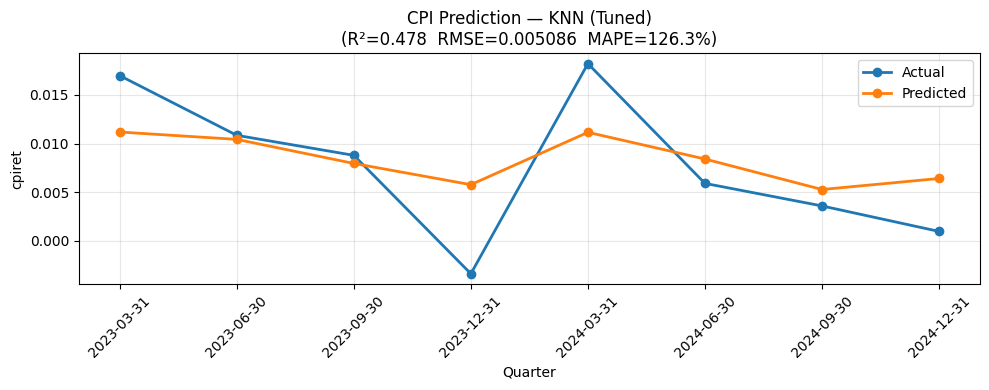

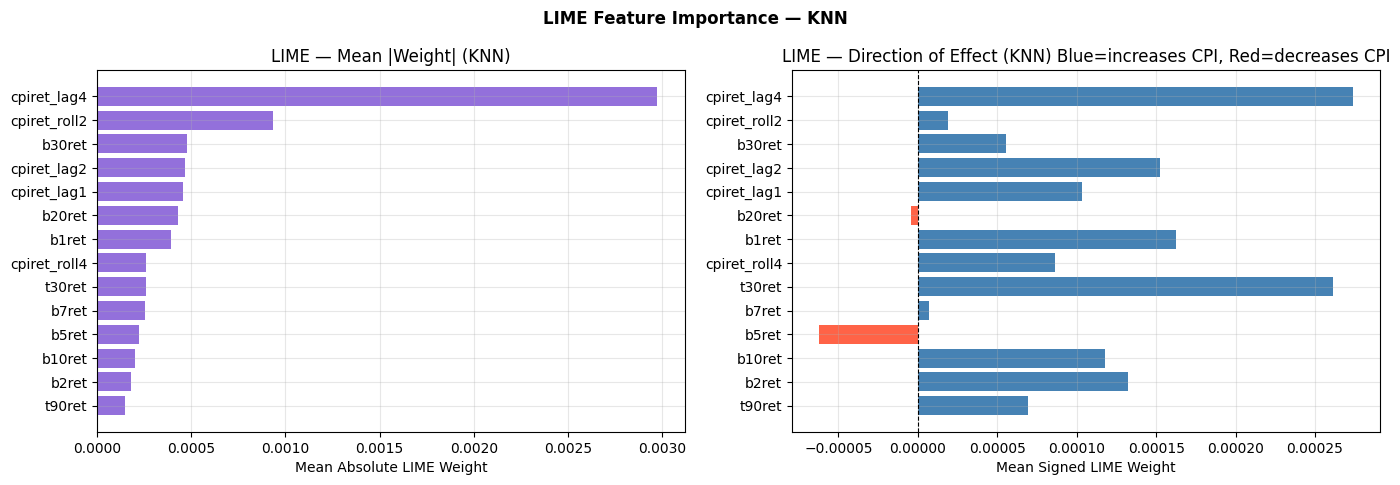

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm, fi_lime = CPI_prediction(
    df, use_macro=False, model='KNN',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='lime',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 41

Tuning KNN with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: -0.0473
  Best params: {'model__weights': 'distance', 'model__n_neighbors': 15, 'model__metric': 'euclidean', 'model__leaf_size': 30}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.007112     0.009866
2023-06-30          0.010843     0.009537     0.001306
2023-09-30          0.008784     0.004741     0.004043
2023-12-31         -0.003388     0.004215     0.007603
2024-03-31          0.018211     0.005274     0.012937
2024-06-30          0.005901     0.006003     0.000102
2024-09-30          0.003584     0.003367     0.000217
2024-12-31          0.000964     0.003802     0.002838
-----------------------------------------------------------------
                                        RMSE:     0.006602
                                    MAPE (%):        89.22
   

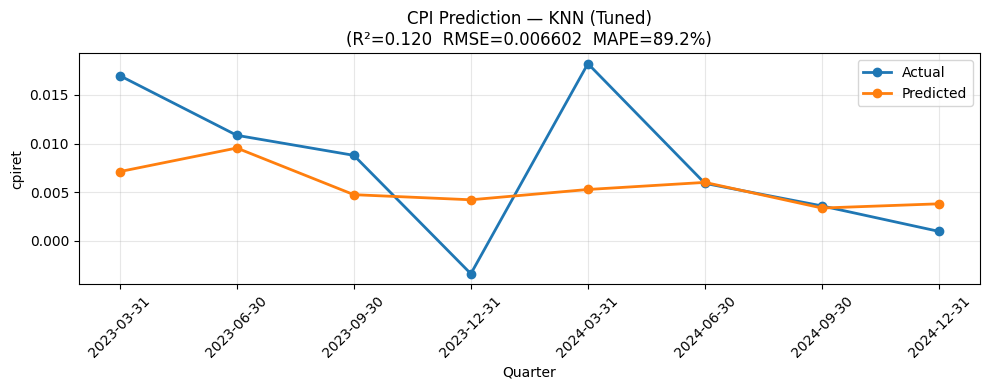

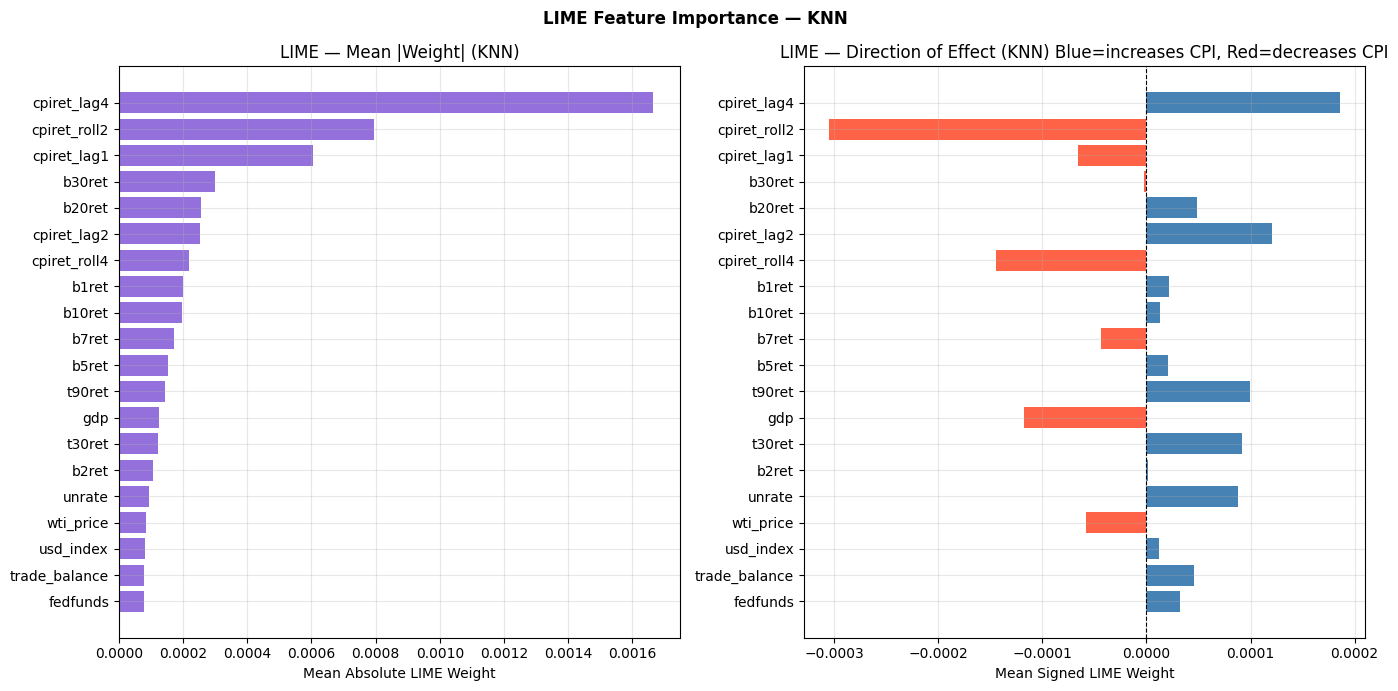

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm, fi_lime = CPI_prediction(
    df, use_macro=True, model='KNN',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='lime',
    tune=True, n_iter=30, cv_splits=5
)

### SVR

Total: 136 | Train: 128 | Test: 8 | Features: 14

Tuning SVR with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: 0.0224
  Best params: {'model__kernel': 'linear', 'model__gamma': 'auto', 'model__epsilon': 0.001, 'model__C': 100.0}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.022442     0.005464
2023-06-30          0.010843     0.026471     0.015628
2023-09-30          0.008784     0.007383     0.001401
2023-12-31         -0.003388     0.000194     0.003582
2024-03-31          0.018211     0.016569     0.001642
2024-06-30          0.005901     0.012878     0.006977
2024-09-30          0.003584     0.002872     0.000712
2024-12-31          0.000964     0.005682     0.004718
-----------------------------------------------------------------
                                        RMSE:     0.006736
                                    MAPE (%):       116.81
                   

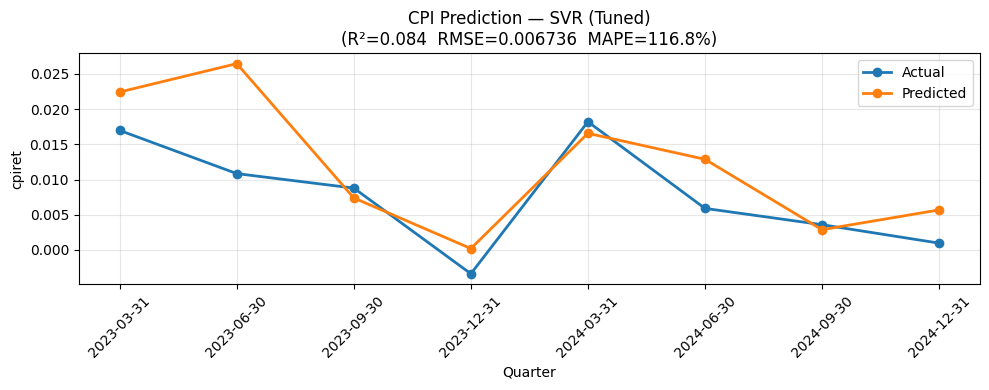

  0%|          | 0/128 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df, use_macro=False, model='SVR',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 40

Tuning SVR with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: -0.1732
  Best params: {'model__kernel': 'rbf', 'model__gamma': 0.1, 'model__epsilon': 0.01, 'model__C': 100.0}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.005806     0.011172
2023-06-30          0.010843     0.006930     0.003913
2023-09-30          0.008784     0.006377     0.002407
2023-12-31         -0.003388     0.005916     0.009304
2024-03-31          0.018211     0.006688     0.011523
2024-06-30          0.005901     0.007367     0.001466
2024-09-30          0.003584     0.005931     0.002347
2024-12-31          0.000964     0.006760     0.005796
-----------------------------------------------------------------
                                        RMSE:     0.007128
                                    MAPE (%):       144.84
                         

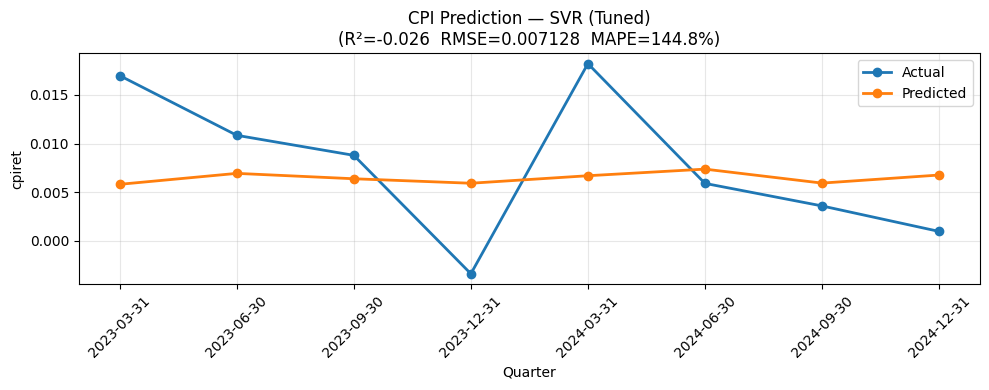

  0%|          | 0/128 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df, use_macro=True, model='SVR',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

### GB

Total: 136 | Train: 128 | Test: 8 | Features: 14

Tuning GB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: 0.0675
  Best params: {'model__subsample': 0.6, 'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 3, 'model__learning_rate': 0.03}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.009960     0.007018
2023-06-30          0.010843     0.019548     0.008705
2023-09-30          0.008784     0.006164     0.002620
2023-12-31         -0.003388    -0.004434     0.001046
2024-03-31          0.018211     0.014345     0.003866
2024-06-30          0.005901     0.010834     0.004933
2024-09-30          0.003584     0.004733     0.001149
2024-12-31          0.000964     0.002100     0.001136
-----------------------------------------------------------------
                                        RMSE:     0.004676
                                    MA

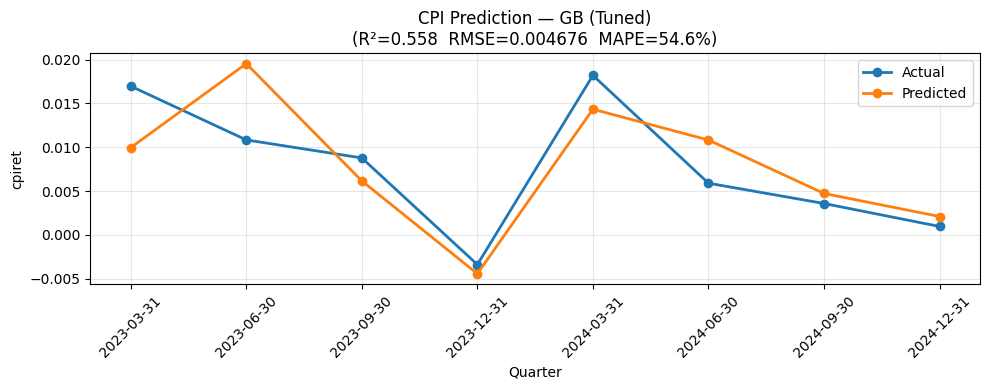

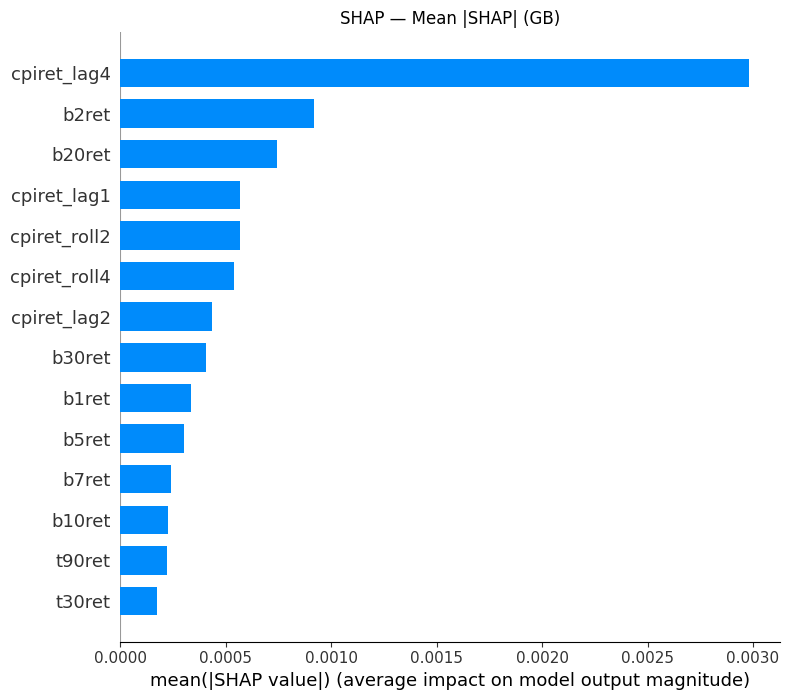

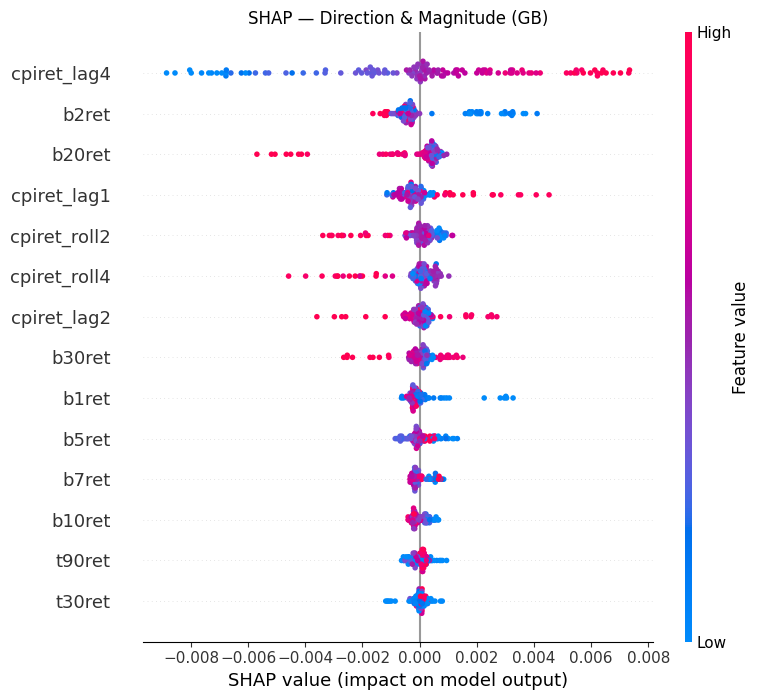

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df, use_macro=False, model='GB',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 40

Tuning GB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: -0.1343
  Best params: {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 3, 'model__learning_rate': 0.01}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.007764     0.009214
2023-06-30          0.010843     0.013876     0.003033
2023-09-30          0.008784     0.007412     0.001372
2023-12-31         -0.003388     0.001349     0.004737
2024-03-31          0.018211     0.009305     0.008906
2024-06-30          0.005901     0.010612     0.004711
2024-09-30          0.003584     0.008288     0.004704
2024-12-31          0.000964     0.010366     0.009402
-----------------------------------------------------------------
                                        RMSE:     0.006427
                                    M

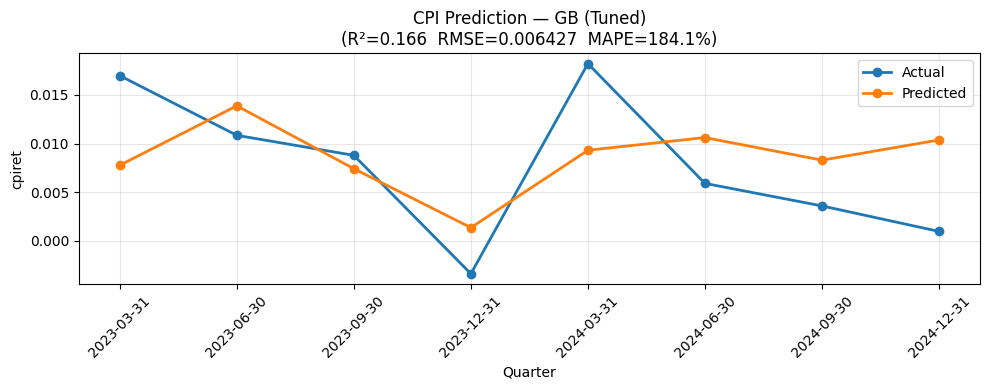

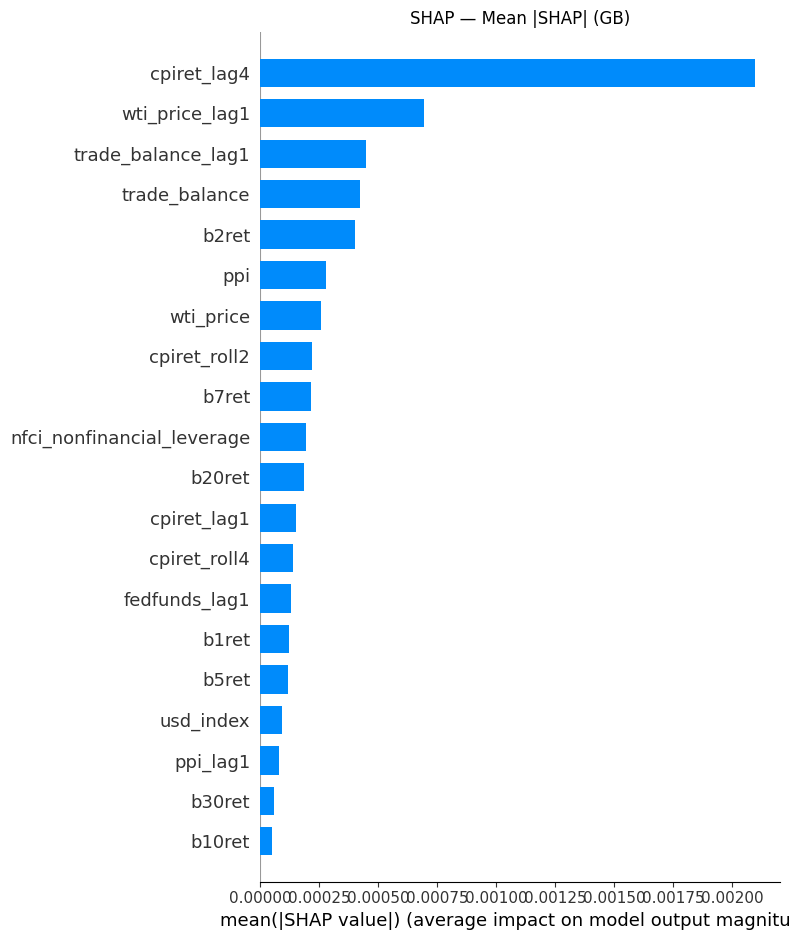

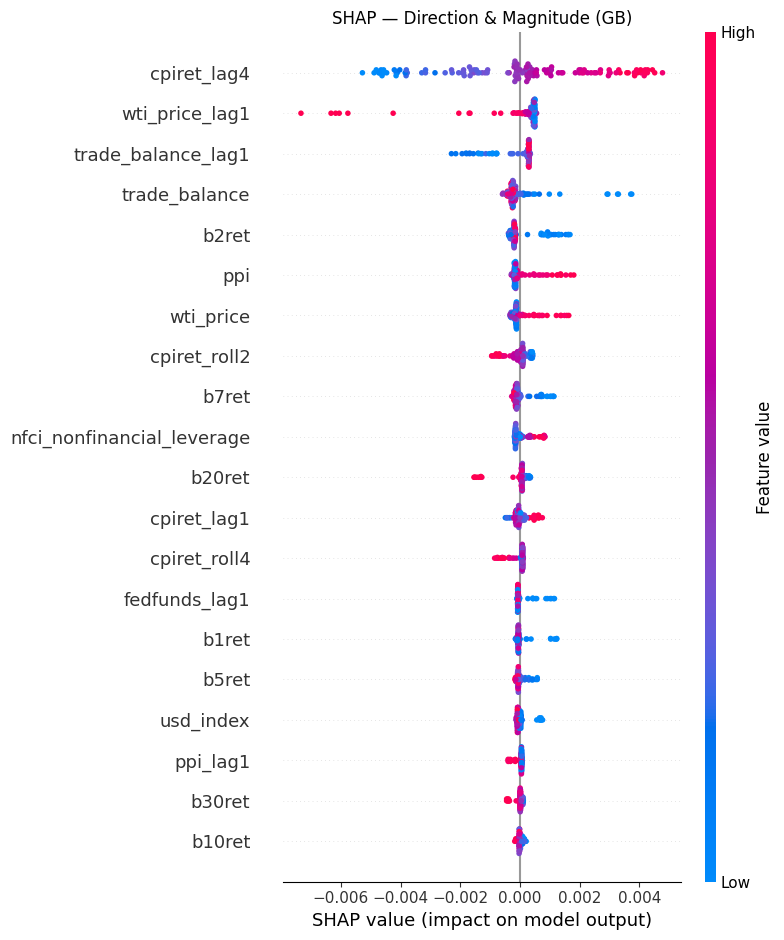

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df, use_macro=True, model='GB',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

### XGB

Total: 136 | Train: 128 | Test: 8 | Features: 14

Tuning XGB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: 0.0001
  Best params: {'model__subsample': 0.7, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.0, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.011322     0.005656
2023-06-30          0.010843     0.016606     0.005763
2023-09-30          0.008784     0.005911     0.002873
2023-12-31         -0.003388     0.001916     0.005304
2024-03-31          0.018211     0.012924     0.005287
2024-06-30          0.005901     0.009280     0.003379
2024-09-30          0.003584     0.005605     0.002021
2024-12-31          0.000964     0.003198     0.002234
-----------------------------------------------------------------
             

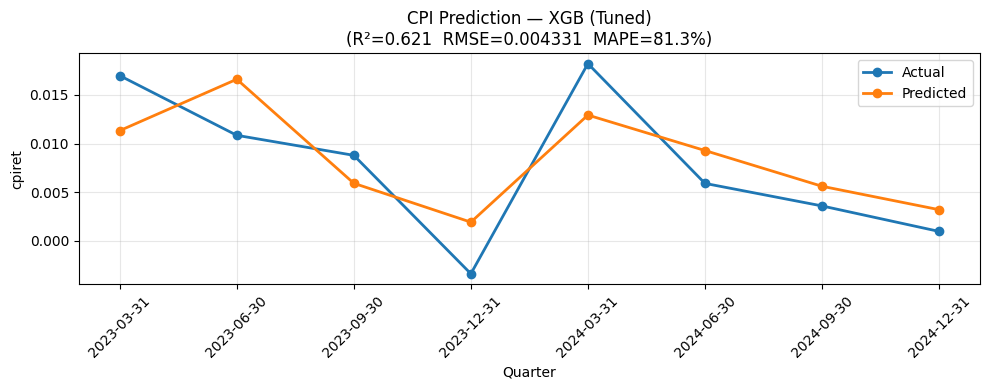

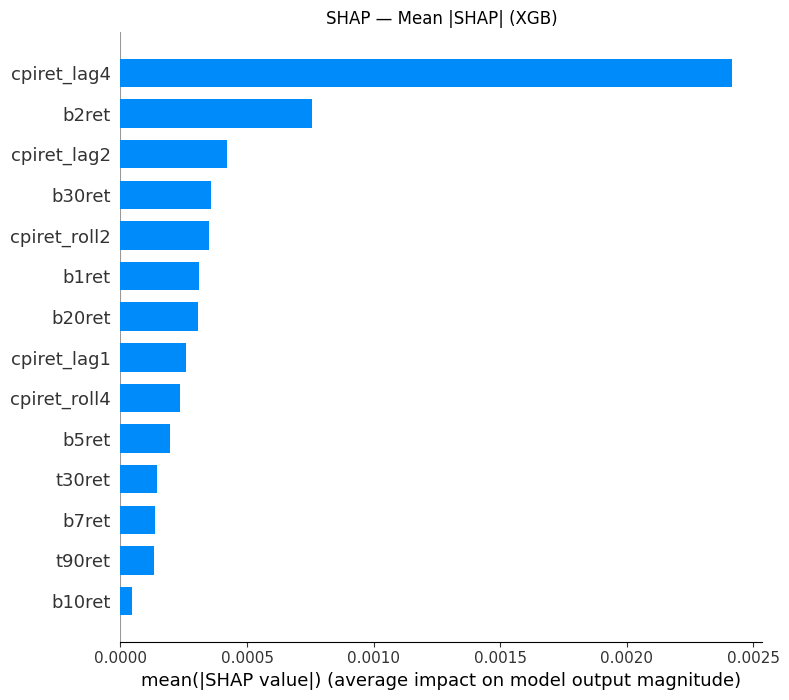

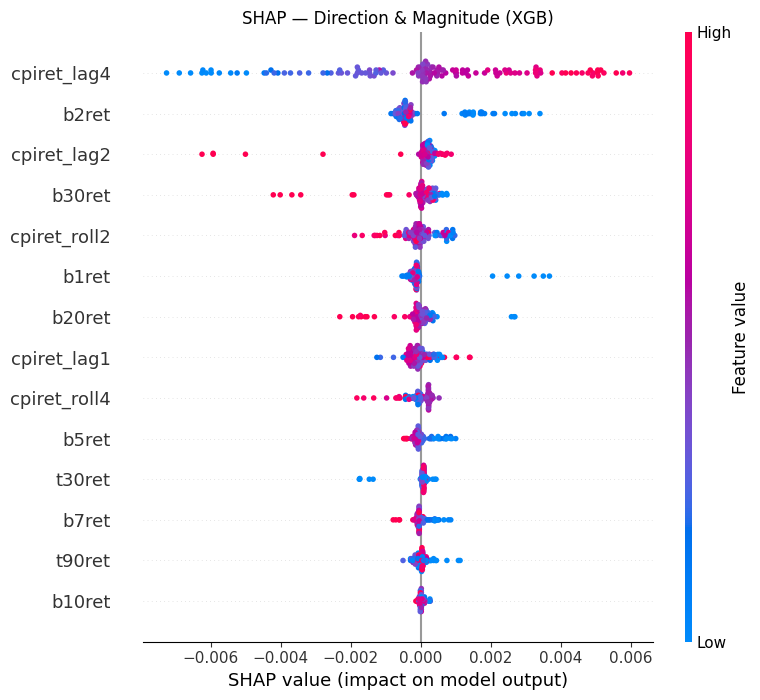

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df, use_macro=False, model='XGB',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 40

Tuning XGB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: -0.0355
  Best params: {'model__subsample': 0.8, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.008936     0.008042
2023-06-30          0.010843     0.012221     0.001378
2023-09-30          0.008784     0.006671     0.002113
2023-12-31         -0.003388     0.004066     0.007454
2024-03-31          0.018211     0.010994     0.007217
2024-06-30          0.005901     0.009792     0.003891
2024-09-30          0.003584     0.005984     0.002400
2024-12-31          0.000964     0.008044     0.007080
-----------------------------------------------------------------
            

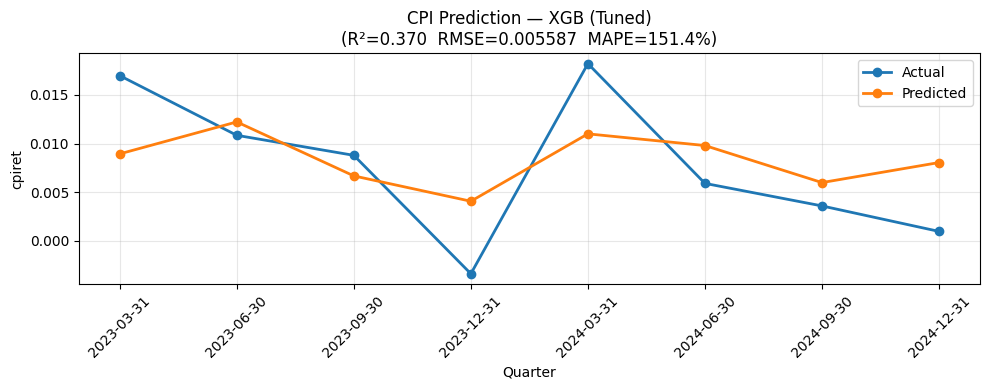

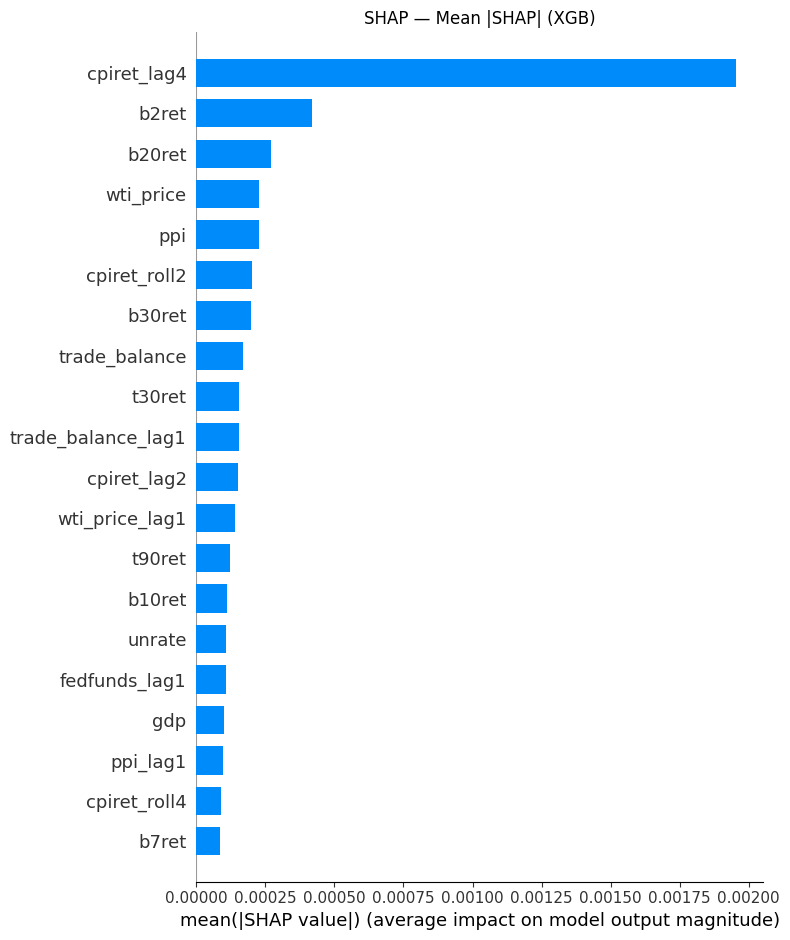

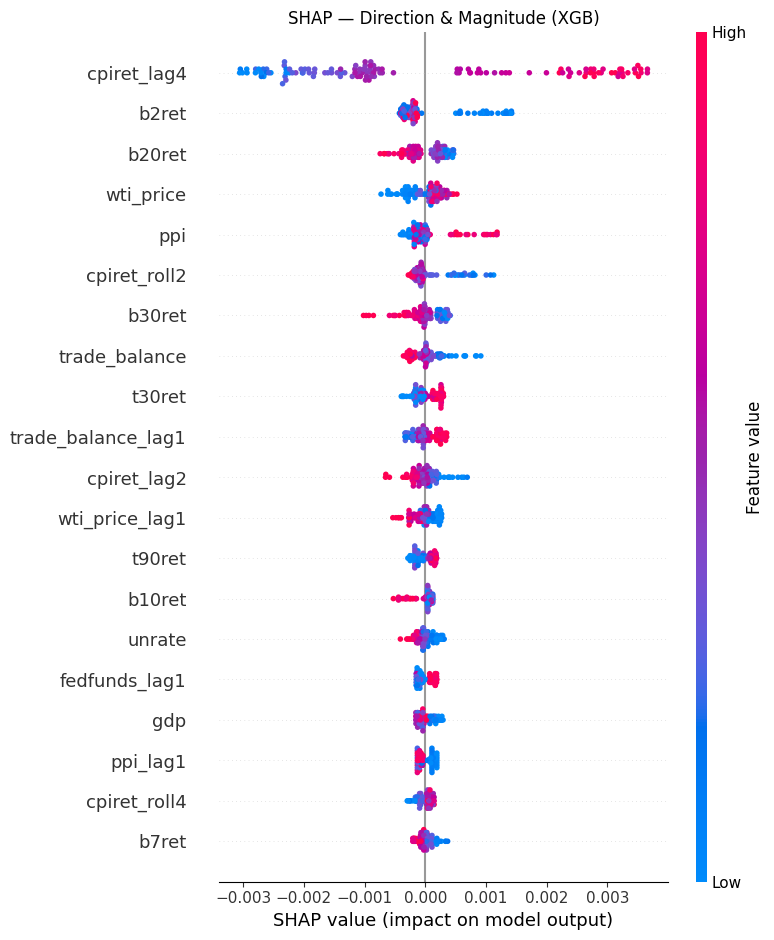

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df, use_macro=True, model='XGB',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

### Catboost

Total: 136 | Train: 128 | Test: 8 | Features: 14

Tuning catboost with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: 0.1047
  Best params: {'model__subsample': 0.7, 'model__learning_rate': 0.05, 'model__l2_leaf_reg': 10.0, 'model__iterations': 300, 'model__depth': 5}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.012315     0.004663
2023-06-30          0.010843     0.013712     0.002869
2023-09-30          0.008784     0.005076     0.003708
2023-12-31         -0.003388     0.003416     0.006804
2024-03-31          0.018211     0.012985     0.005226
2024-06-30          0.005901     0.009510     0.003609
2024-09-30          0.003584     0.004406     0.000822
2024-12-31          0.000964     0.004046     0.003082
-----------------------------------------------------------------
                                        RMSE:     0.004191
                                    MAPE

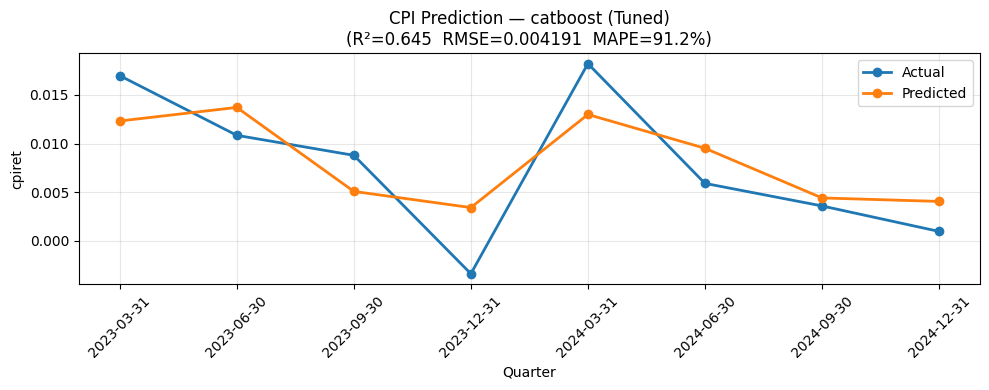

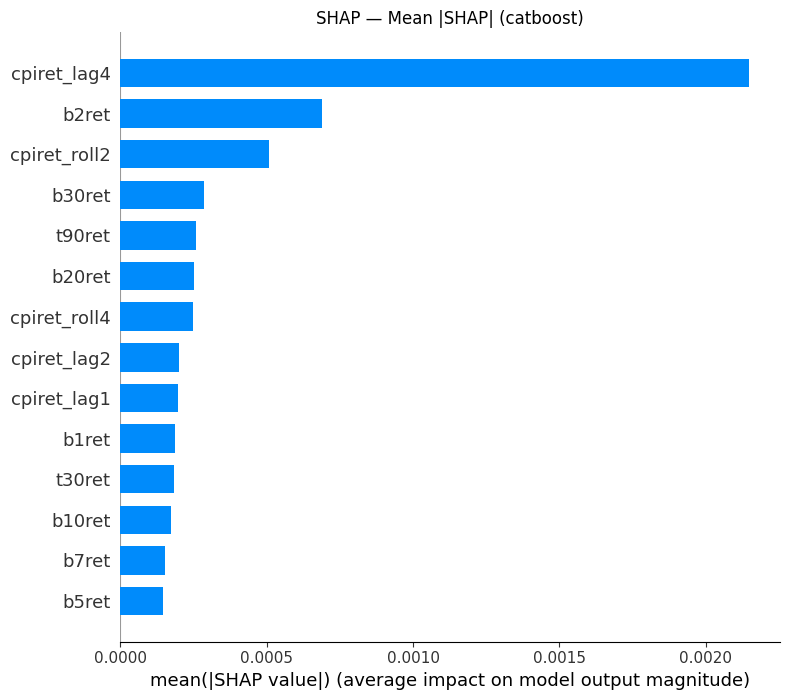

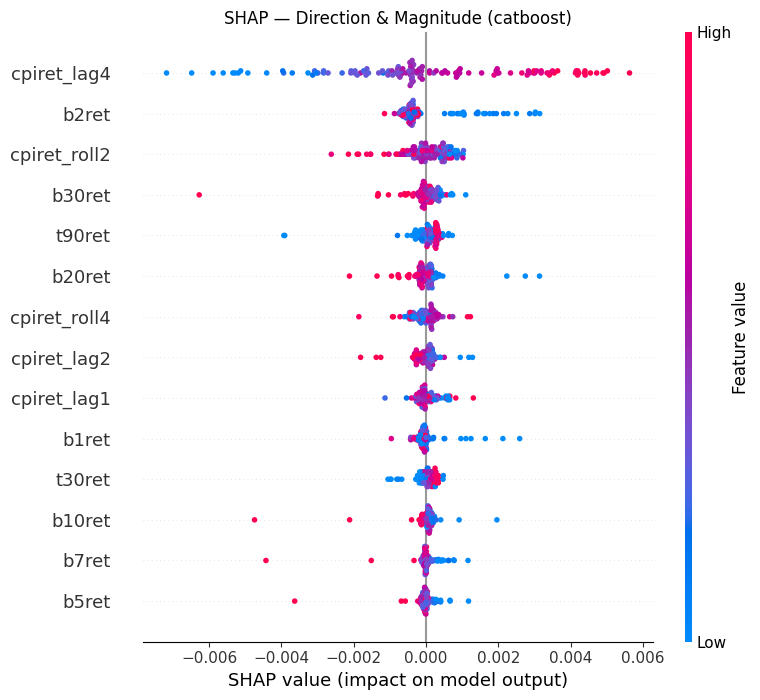

In [ ]:

results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df, use_macro=False, model='catboost',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 40

Tuning catboost with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: 0.0118
  Best params: {'model__subsample': 0.6, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 10.0, 'model__iterations': 800, 'model__depth': 5}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.007943     0.009035
2023-06-30          0.010843     0.011112     0.000269
2023-09-30          0.008784     0.005413     0.003371
2023-12-31         -0.003388     0.000689     0.004077
2024-03-31          0.018211     0.010143     0.008068
2024-06-30          0.005901     0.008442     0.002541
2024-09-30          0.003584     0.006206     0.002622
2024-12-31          0.000964     0.009333     0.008369
-----------------------------------------------------------------
                                        RMSE:     0.005680
                                    MAPE

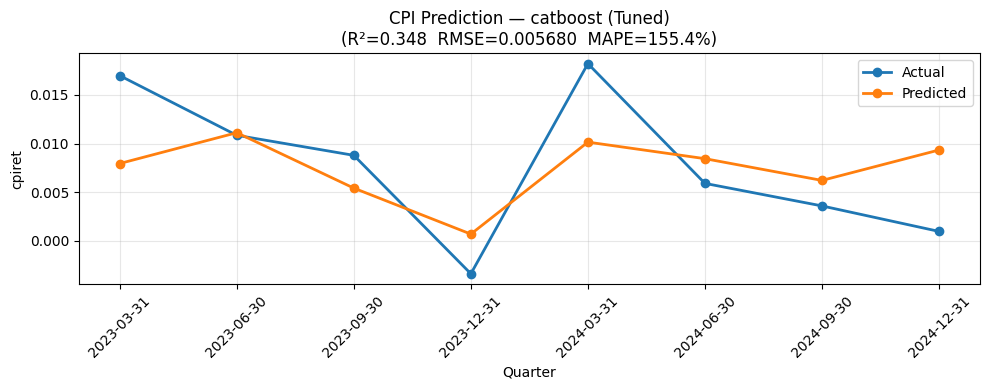

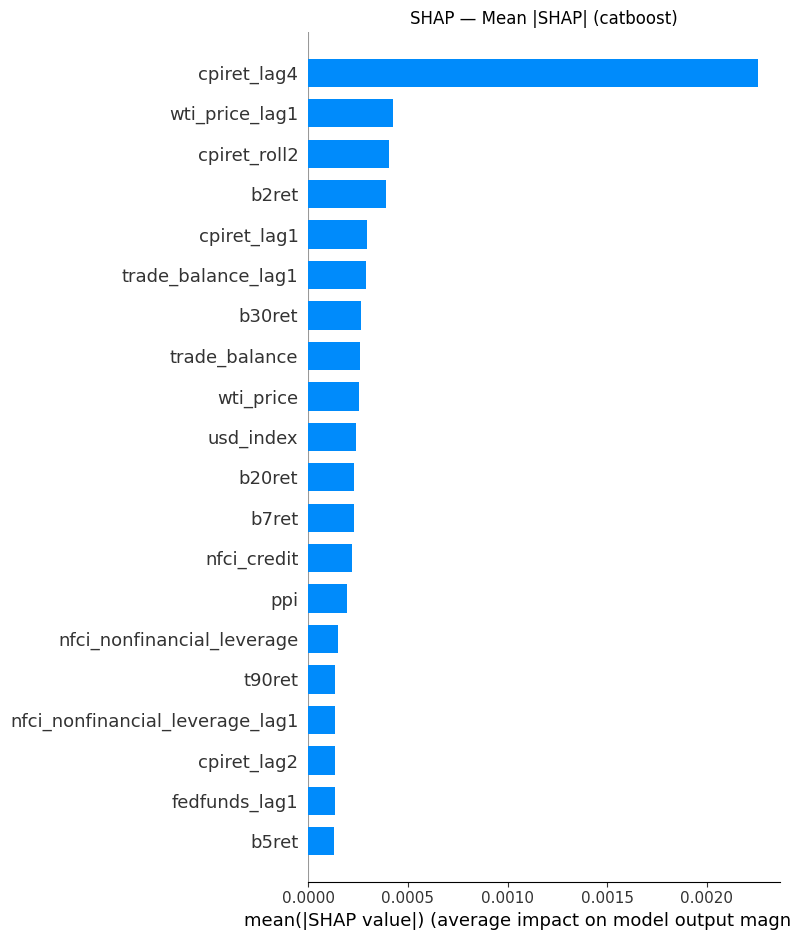

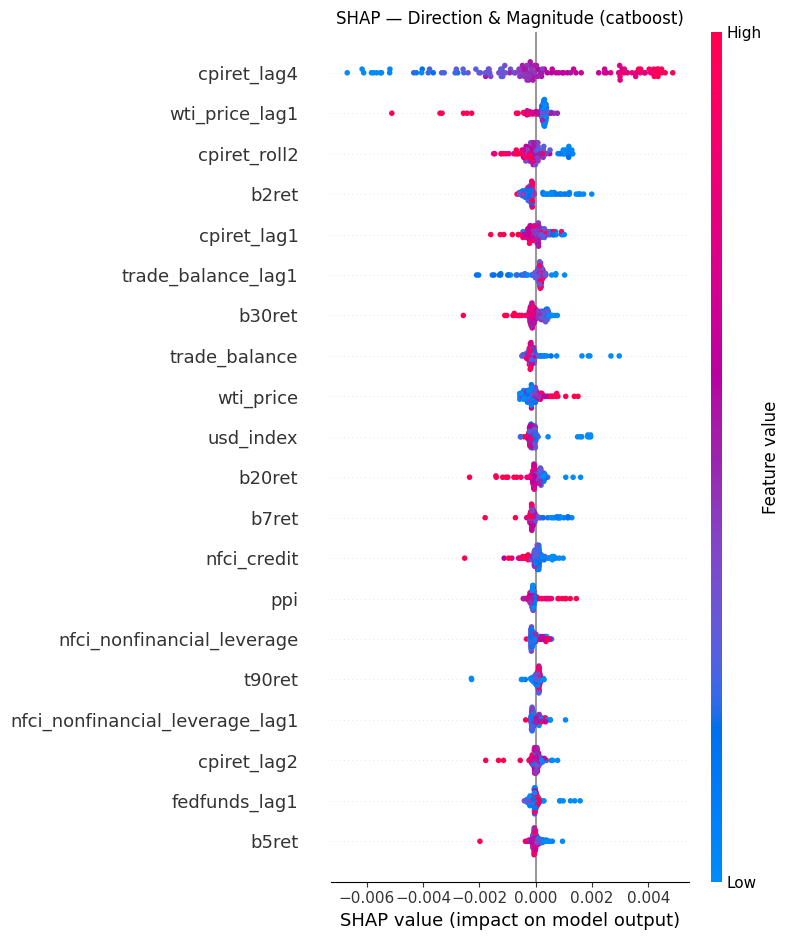

In [ ]:

results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df, use_macro=True, model='catboost',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

### bayes

Total: 136 | Train: 128 | Test: 8 | Features: 14

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: 0.1474
  Best params: {'model__max_iter': 1000, 'model__lambda_2': 1e-05, 'model__lambda_1': 1e-06, 'model__alpha_2': 1e-05, 'model__alpha_1': 1e-06}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.014827     0.002151
2023-06-30          0.010843     0.022812     0.011969
2023-09-30          0.008784     0.009085     0.000301
2023-12-31         -0.003388    -0.001686     0.001702
2024-03-31          0.018211     0.014322     0.003889
2024-06-30          0.005901     0.012091     0.006190
2024-09-30          0.003584     0.003279     0.000305
2024-12-31          0.000964     0.006333     0.005369
-----------------------------------------------------------------
                                        RMSE:     0.005399
                                    MAPE (%)

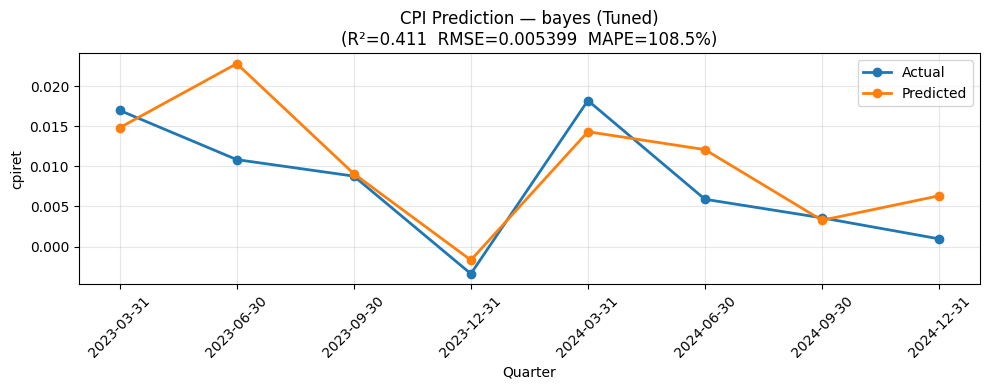

  0%|          | 0/128 [00:00<?, ?it/s]

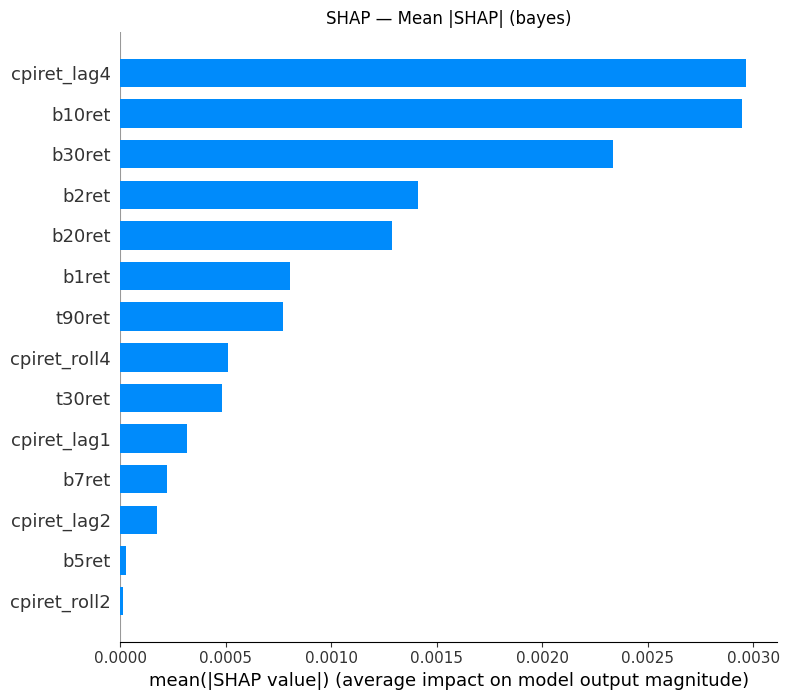

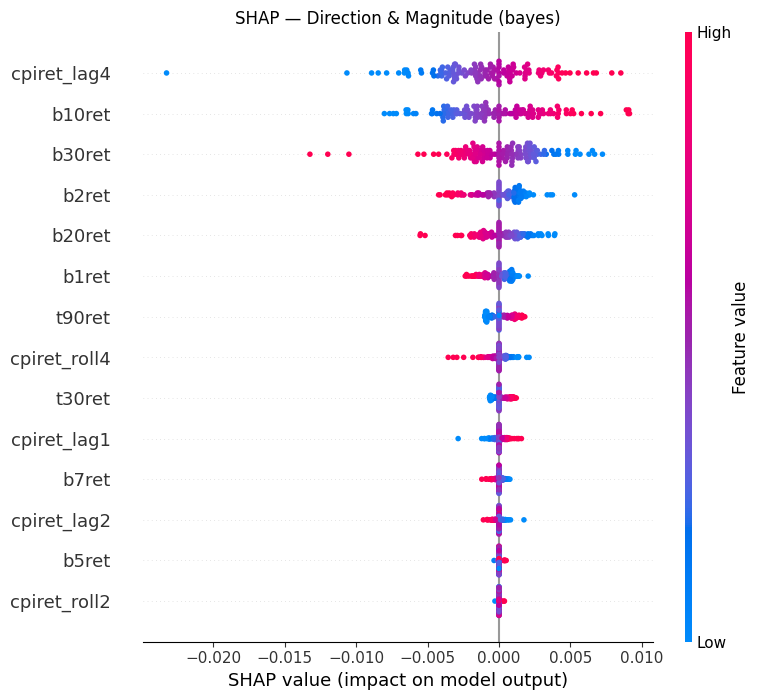

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df, use_macro=False, model='bayes',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 14

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: 0.1474
  Best params: {'model__max_iter': 1000, 'model__lambda_2': 1e-05, 'model__lambda_1': 1e-06, 'model__alpha_2': 1e-05, 'model__alpha_1': 1e-06}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.014827     0.002151
2023-06-30          0.010843     0.022812     0.011969
2023-09-30          0.008784     0.009085     0.000301
2023-12-31         -0.003388    -0.001686     0.001702
2024-03-31          0.018211     0.014322     0.003889
2024-06-30          0.005901     0.012091     0.006190
2024-09-30          0.003584     0.003279     0.000305
2024-12-31          0.000964     0.006333     0.005369
-----------------------------------------------------------------
                                        RMSE:     0.005399
                                    MAPE (%)

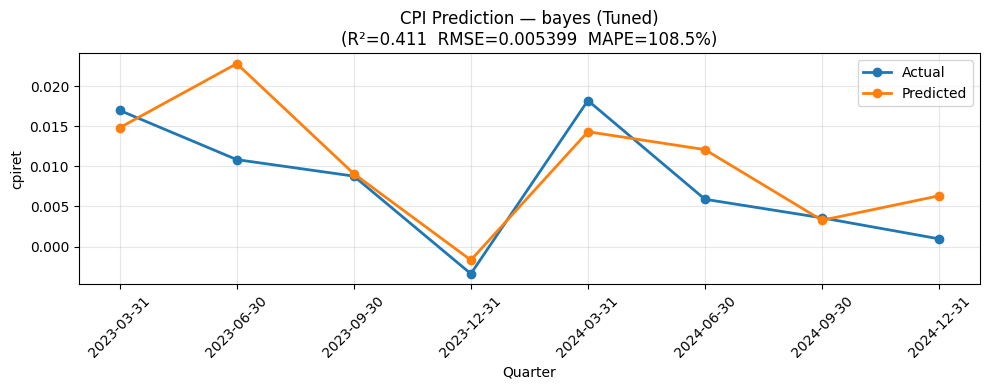

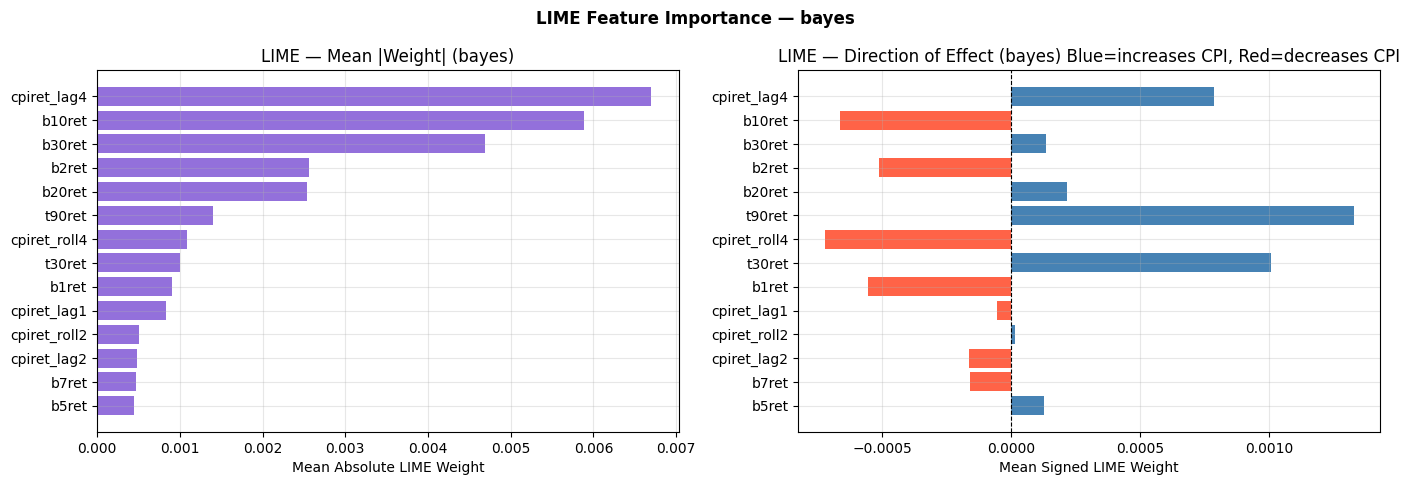

In [ ]:
results, rmse, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = CPI_prediction(
    df, use_macro=False, model='bayes',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='lime',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 40

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: -1.1610
  Best params: {'model__max_iter': 500, 'model__lambda_2': 1e-07, 'model__lambda_1': 1e-05, 'model__alpha_2': 1e-05, 'model__alpha_1': 1e-07}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.014183     0.002795
2023-06-30          0.010843     0.017445     0.006602
2023-09-30          0.008784     0.007100     0.001684
2023-12-31         -0.003388    -0.003178     0.000210
2024-03-31          0.018211     0.012261     0.005950
2024-06-30          0.005901     0.008196     0.002295
2024-09-30          0.003584     0.006061     0.002477
2024-12-31          0.000964     0.007263     0.006299
-----------------------------------------------------------------
                                        RMSE:     0.004195
                                    MAPE (%)

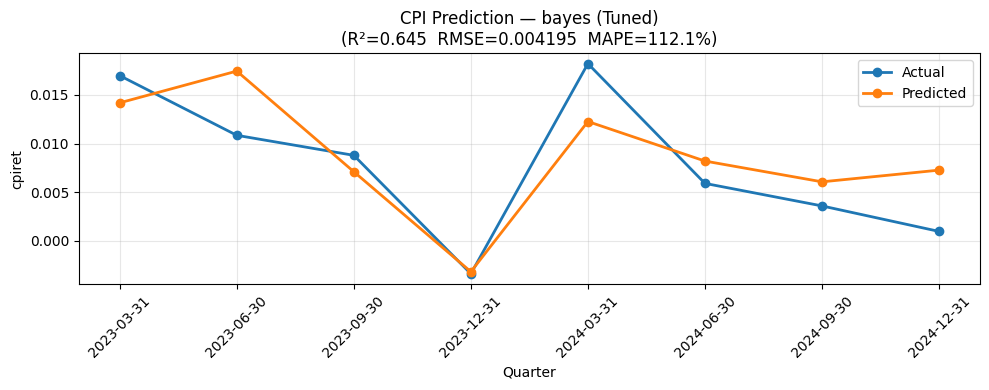

  0%|          | 0/128 [00:00<?, ?it/s]

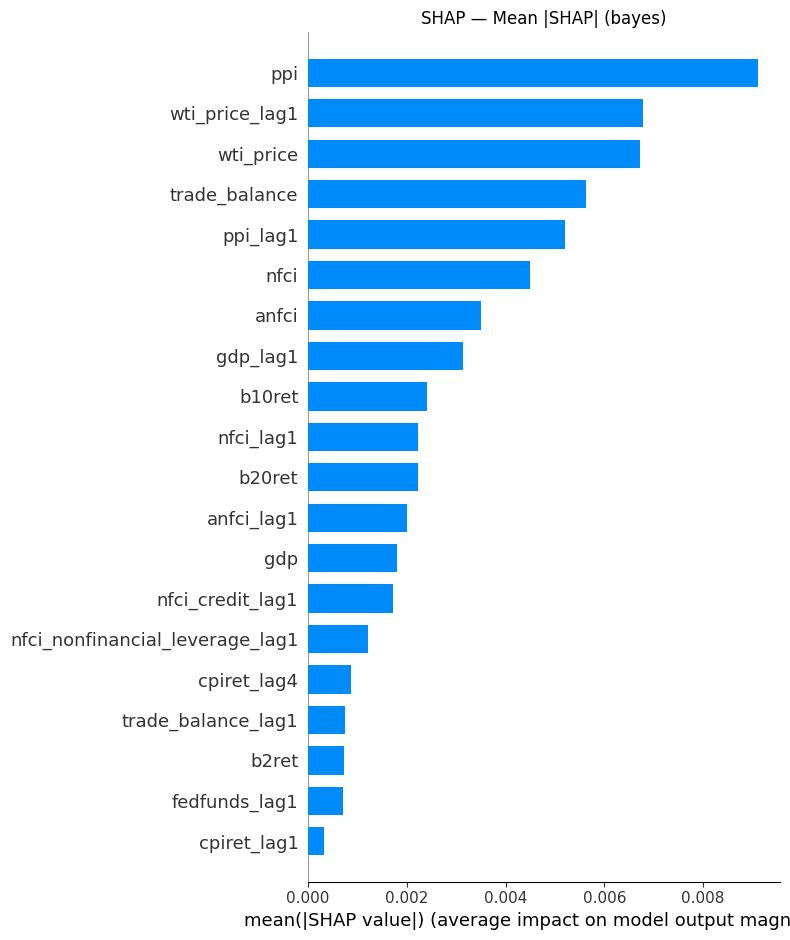

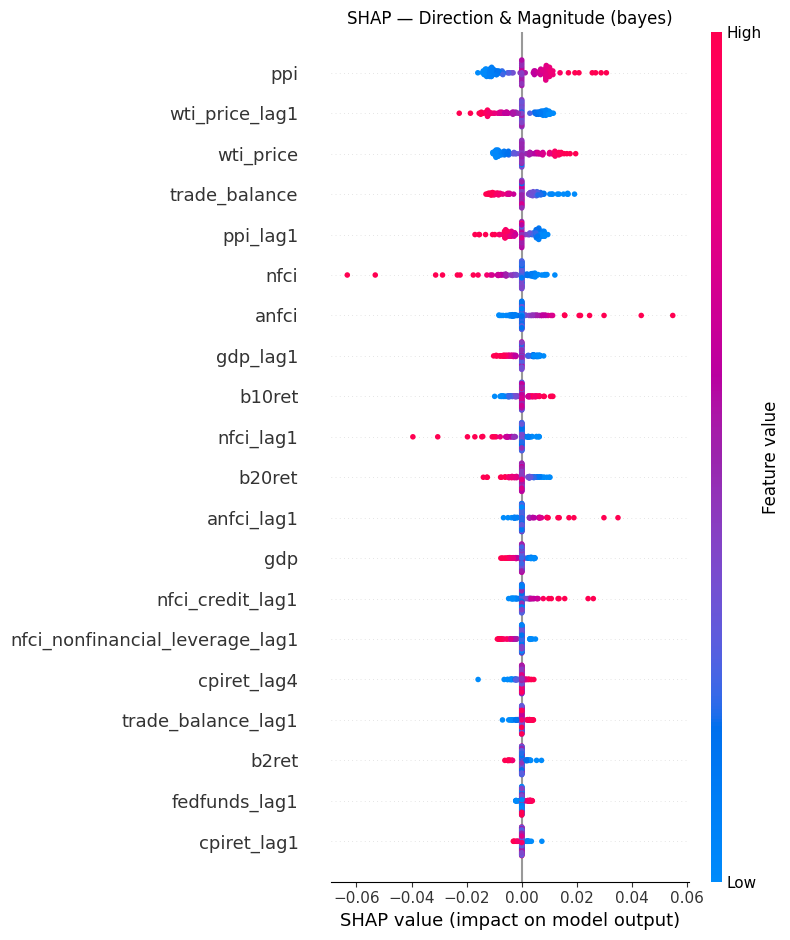

In [ ]:
results, rmse, mape, r2, fi_std, fi_shap, fi_perm = CPI_prediction(
    df, use_macro=True, model='bayes',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 42

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²: -1.7853
  Best params: {'model__max_iter': 500, 'model__lambda_2': 1e-07, 'model__lambda_1': 1e-05, 'model__alpha_2': 1e-05, 'model__alpha_1': 1e-07}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.015032     0.001946
2023-06-30          0.010843     0.017713     0.006870
2023-09-30          0.008784     0.007169     0.001615
2023-12-31         -0.003388    -0.002497     0.000891
2024-03-31          0.018211     0.012131     0.006080
2024-06-30          0.005901     0.008460     0.002559
2024-09-30          0.003584     0.006218     0.002634
2024-12-31          0.000964     0.006139     0.005175
-----------------------------------------------------------------
                                        RMSE:     0.004056
                                    MAPE (%)

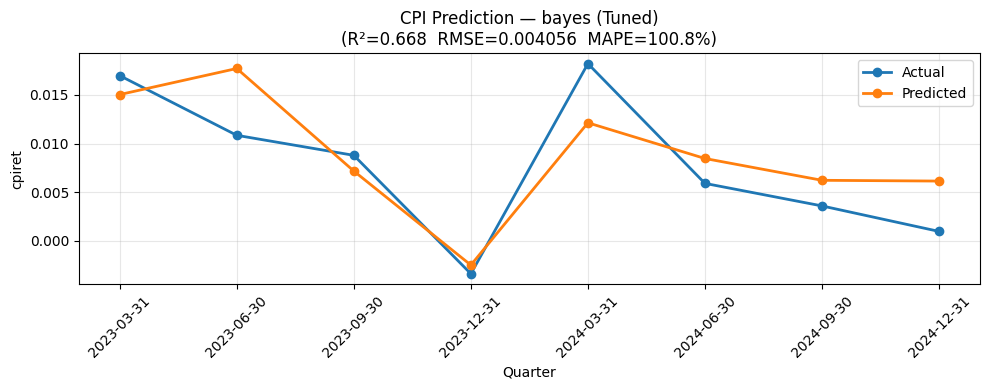

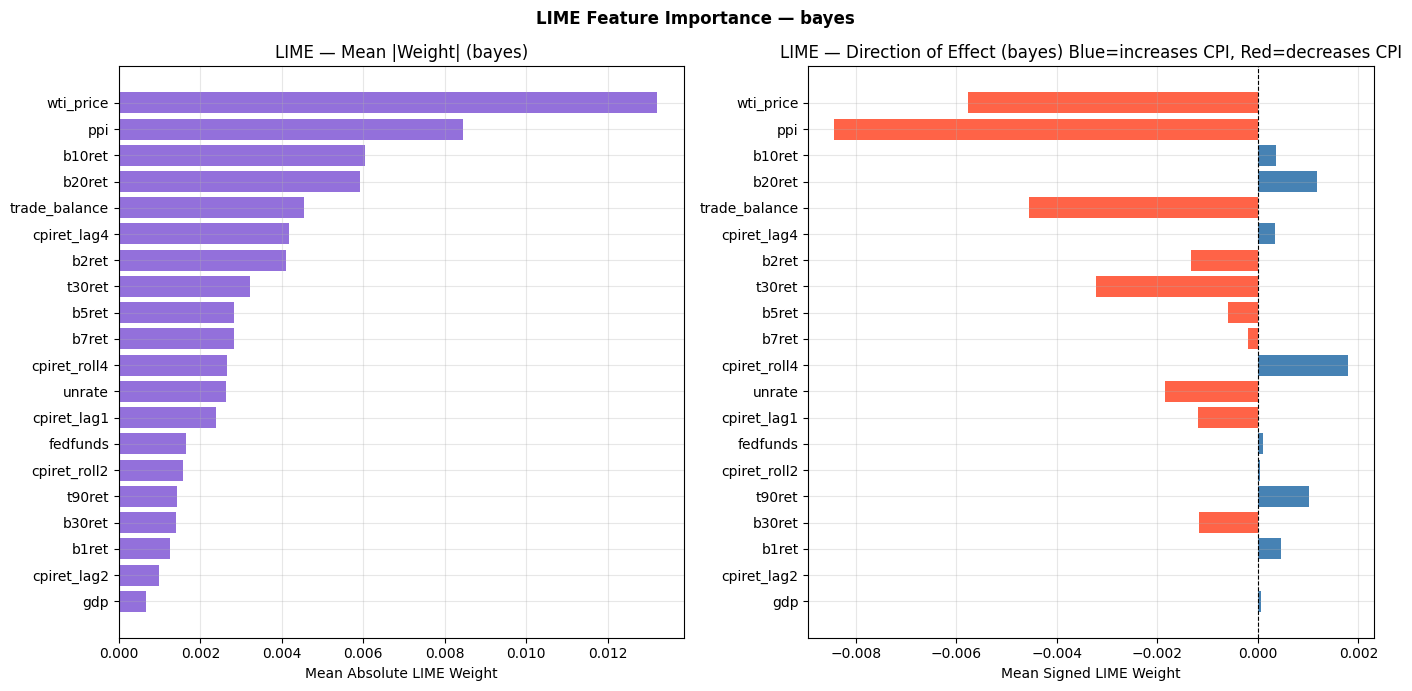

In [ ]:
results, rmse, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime = CPI_prediction(
    df, use_macro=True, model='bayes',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='lime',
    tune=True, n_iter=30, cv_splits=5
)

### Arima

Total: 136 | Train: 128 | Test: 8 | Features: 14


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



ARIMA — Best AIC: -828.34
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.018823     0.001845
2023-06-30          0.010843     0.019663     0.008820
2023-09-30          0.008784     0.001063     0.007721
2023-12-31         -0.003388    -0.000027     0.003361
2024-03-31          0.018211     0.012195     0.006016
2024-06-30          0.005901     0.012740     0.006839
2024-09-30          0.003584     0.000689     0.002895
2024-12-31          0.000964    -0.000018     0.000982
-----------------------------------------------------------------
                                        RMSE:     0.005527
                                    MAPE (%):        76.36
                                          R²:       0.3829

Note: ARIMA coefficients:
ar.L1      0.131329
ar.S.L4    0.647879
sigma2     0.000066
dtype: float64


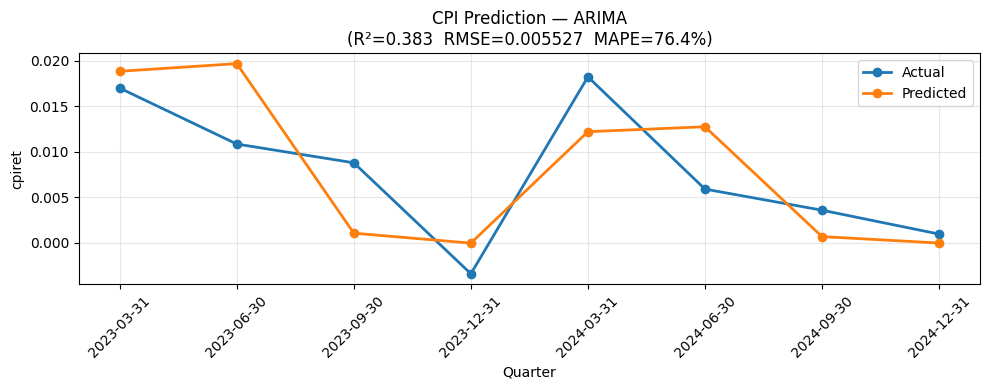

In [ ]:
results, rmse, mape, r2 = CPI_prediction(
    df, use_macro=False, model='arima',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 40


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


ARIMA — Best AIC: -989.54
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.011554     0.005424
2023-06-30          0.010843     0.013899     0.003056
2023-09-30          0.008784     0.011255     0.002471
2023-12-31         -0.003388    -0.008779     0.005391
2024-03-31          0.018211     0.015010     0.003201
2024-06-30          0.005901     0.006775     0.000874
2024-09-30          0.003584     0.004034     0.000450
2024-12-31          0.000964     0.003859     0.002895
-----------------------------------------------------------------
                                        RMSE:     0.003419
                                    MAPE (%):        74.08
                                          R²:       0.7639

Note: ARIMA coefficients:
x1         2.491546e-02
x2        -4.247012e-02
x3         2.487434e-02
x4        -8.318187e-02
x5         2.131756e-01
x6        -4.405880e-0

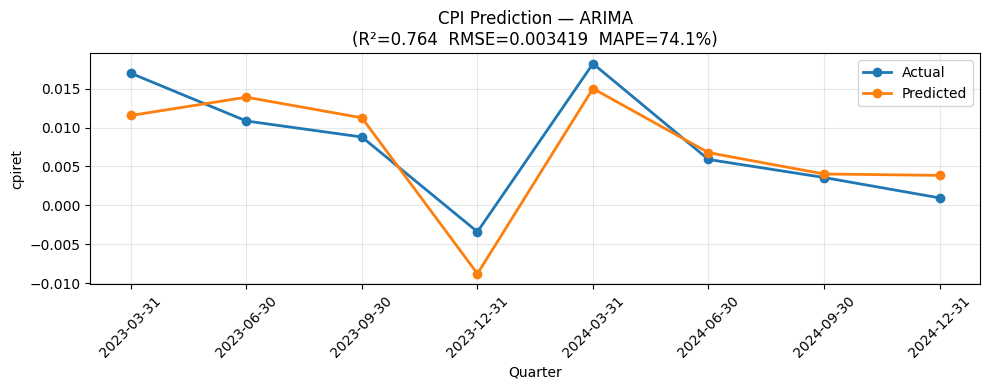

In [ ]:
results, rmse, mape, r2 = CPI_prediction(
    df, use_macro=True, model='arima',
    use_scaling=True, test_quarters=8, use_rolling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

### Regresssion TM

Total: 136 | Train: 128 | Test: 8 | Features: 14

Running Optuna tuning for Tsetlin CPI (expanded search)...


  0%|          | 0/50 [00:00<?, ?it/s]


  Best Optuna CV R²: -0.4247
  Best params:       {'n_bins': 9, 'number_of_clauses': 4000, 'T': 1000, 's': 5.5078492072104845, 'epochs': 100}

Fitting Tsetlin — clauses=4000, T=1000, s=5.508, epochs=100, n_bins=9

Tsetlin Machine — CPI (Tuned)
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978    -0.012594     0.029572
2023-06-30          0.010843     0.007797     0.003046
2023-09-30          0.008784     0.004000     0.004784
2023-12-31         -0.003388    -0.007250     0.003862
2024-03-31          0.018211    -0.000711     0.018922
2024-06-30          0.005901     0.004000     0.001901
2024-09-30          0.003584     0.004000     0.000416
2024-12-31          0.000964     0.004000     0.003036
-----------------------------------------------------------------
                                        RMSE:     0.012711
                                    MAPE (%):       104.18
          

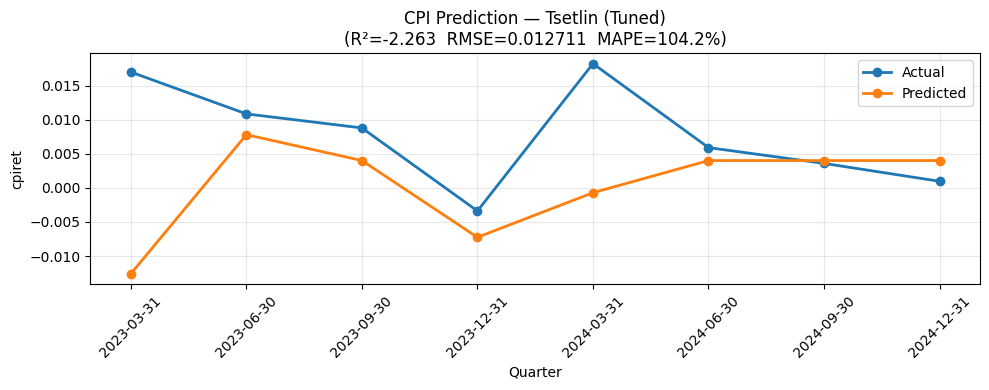

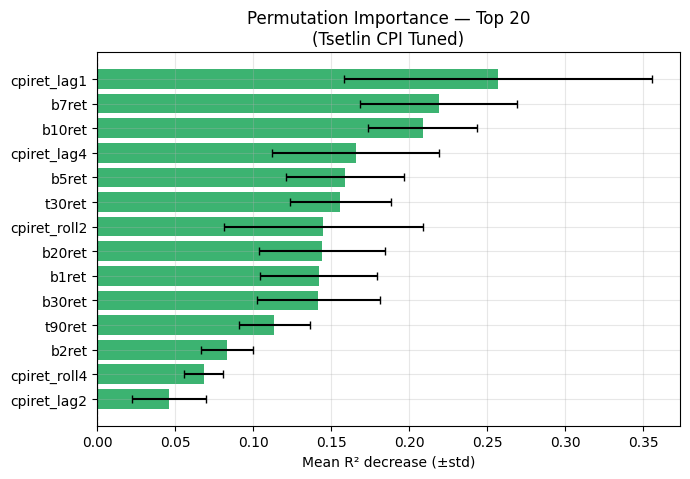

In [ ]:
results, rmse, mape, r2, fi_perm = CPI_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=False, test_quarters=8,
    tune=True, n_iter=30
)

Total: 136 | Train: 128 | Test: 8 | Features: 14

Running Optuna tuning for Tsetlin Machine...


  0%|          | 0/30 [00:00<?, ?it/s]

  Best Optuna R² (CV): -0.7253
  Best params: {'number_of_clauses': 500, 'T': 100, 's': 4.565127799908959, 'epochs': 20}

Tsetlin Machine — CPI
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978    -0.006758     0.023736
2023-06-30          0.010843     0.010821     0.000022
2023-09-30          0.008784    -0.013086     0.021870
2023-12-31         -0.003388    -0.006054     0.002666
2024-03-31          0.018211    -0.010976     0.029187
2024-06-30          0.005901    -0.001132     0.007033
2024-09-30          0.003584    -0.001132     0.004716
2024-12-31          0.000964    -0.003242     0.004206
-----------------------------------------------------------------
                                        RMSE:     0.015772
                                    MAPE (%):       164.38
                                          R²:      -4.0242


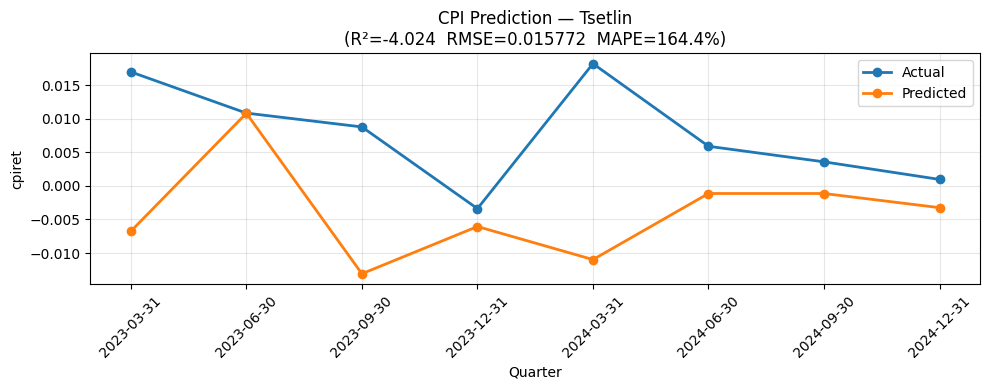

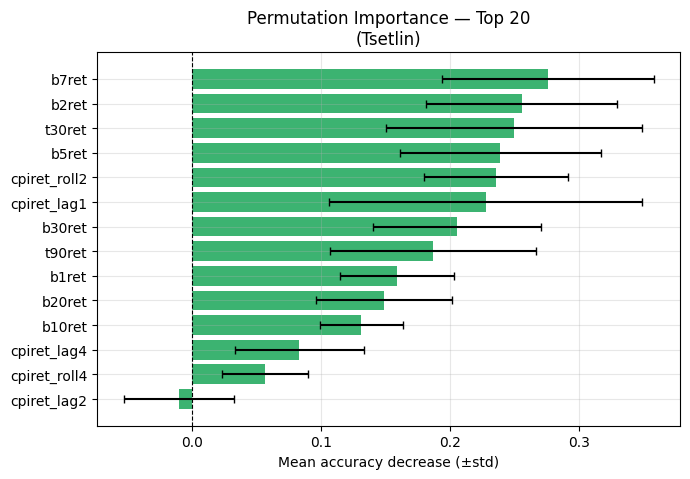

In [ ]:
results, rmse, mape, r2, fi_perm = CPI_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=False, test_quarters=8,
    tune=True, n_iter=30
)

In [ ]:
results, rmse, mape, r2, fi_perm = CPI_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=False, test_quarters=8,
    tune=True, n_iter=30
)

Total: 136 | Train: 128 | Test: 8 | Features: 41

Running Optuna tuning for Tsetlin CPI (expanded search)...


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 35 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 35 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 35 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 35 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py

Total: 136 | Train: 128 | Test: 8 | Features: 40

Running Optuna tuning for Tsetlin Machine...


  0%|          | 0/30 [00:00<?, ?it/s]

  Best Optuna R² (CV): -1.0400
  Best params: {'number_of_clauses': 4000, 'T': 1000, 's': 4.535069996083838, 'epochs': 50}

Tsetlin Machine — CPI
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978    -0.005211     0.022189
2023-06-30          0.010843    -0.004648     0.015491
2023-09-30          0.008784    -0.001765     0.010549
2023-12-31         -0.003388    -0.003875     0.000487
2024-03-31          0.018211    -0.001484     0.019695
2024-06-30          0.005901     0.000063     0.005838
2024-09-30          0.003584     0.000063     0.003521
2024-12-31          0.000964     0.003227     0.002263
-----------------------------------------------------------------
                                        RMSE:     0.012666
                                    MAPE (%):       118.51
                                          R²:      -2.2399


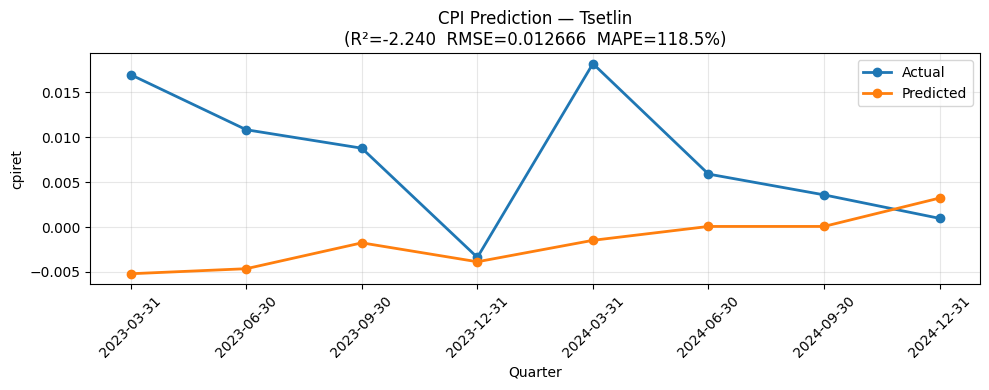

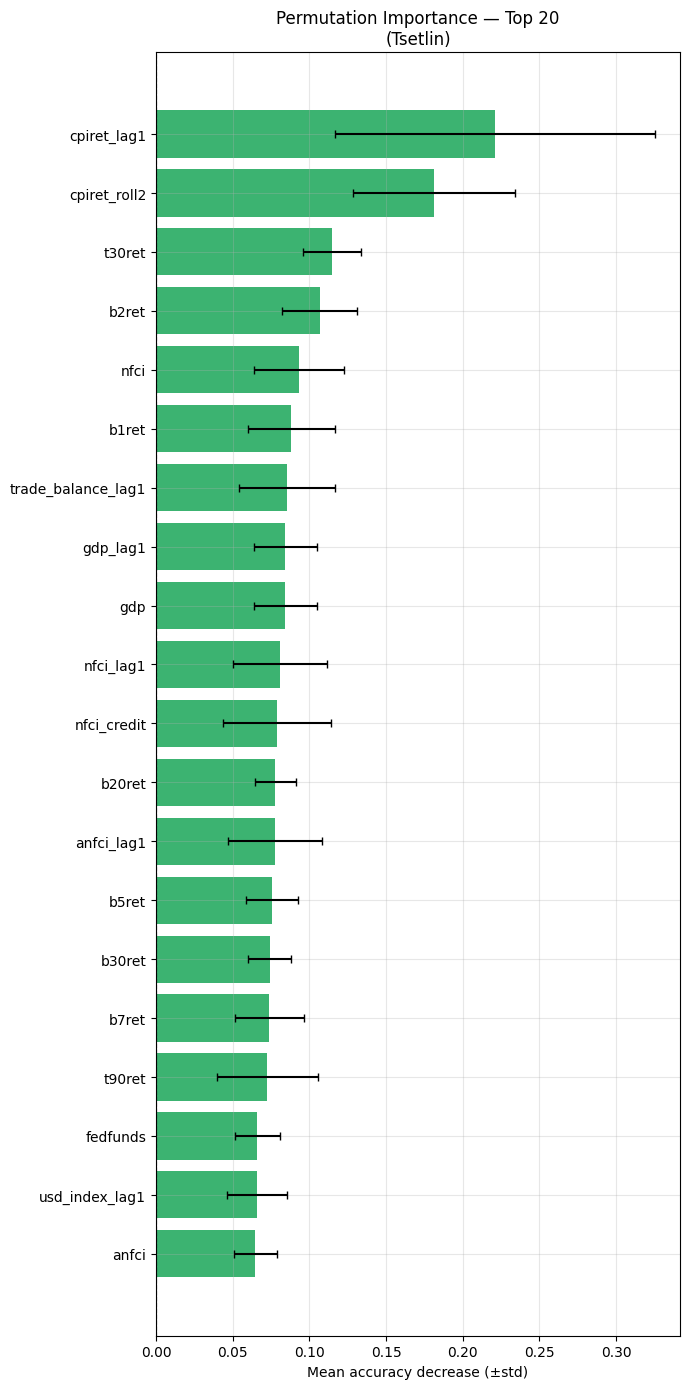

In [ ]:
results, rmse, mape, r2, fi_perm = CPI_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=False, test_quarters=8,
    tune=True, n_iter=30
)

## Aggregate feature importance

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def aggregate_feature_importance(importance_results: dict,
                                  method: str = 'borda',
                                  top_n: int = 20) -> pd.DataFrame:

    model_names = list(importance_results.keys())
    n_models    = len(model_names)

    all_features = set()
    for fi_df in importance_results.values():
        all_features.update(fi_df['feature'].tolist())
    all_features = sorted(all_features)
    n_features   = len(all_features)

    rank_matrix  = pd.DataFrame(index=all_features, columns=model_names, dtype=float)
    score_matrix = pd.DataFrame(index=all_features, columns=model_names, dtype=float)

    for model_name, fi_df in importance_results.items():
        fi_df = fi_df.copy().reset_index(drop=True)
        fi_df['rank'] = fi_df['importance'].rank(ascending=False, method='min')

        imp_min = fi_df['importance'].min()
        imp_max = fi_df['importance'].max()
        denom   = imp_max - imp_min if imp_max != imp_min else 1.0
        fi_df['norm_score'] = (fi_df['importance'] - imp_min) / denom

        for _, row in fi_df.iterrows():
            rank_matrix.loc[row['feature'],  model_name] = row['rank']
            score_matrix.loc[row['feature'], model_name] = row['norm_score']


        missing = set(all_features) - set(fi_df['feature'])
        for f in missing:
            rank_matrix.loc[f,  model_name] = n_features + 1
            score_matrix.loc[f, model_name] = 0.0

    # Borda Count
    borda_scores = pd.Series(0.0, index=all_features)
    for model_name in model_names:
        borda_scores += (n_features + 1) - rank_matrix[model_name]

    borda_df = pd.DataFrame({
        'feature':     all_features,
        'borda_score': borda_scores.values,
        'borda_rank':  borda_scores.rank(ascending=False, method='min').astype(int)
    }).sort_values('borda_score', ascending=False).reset_index(drop=True)

    # Mean Rank
    mean_rank = rank_matrix.mean(axis=1)
    std_rank  = rank_matrix.std(axis=1)

    mean_rank_df = pd.DataFrame({
        'feature':   all_features,
        'mean_rank': mean_rank.values,
        'std_rank':  std_rank.values,
        'mean_rank_rank': mean_rank.rank(ascending=True, method='min').astype(int)
    }).sort_values('mean_rank').reset_index(drop=True)

    #  Mean Normalised Score
    mean_score = score_matrix.mean(axis=1)
    std_score  = score_matrix.std(axis=1)

    mean_score_df = pd.DataFrame({
        'feature':    all_features,
        'mean_score': mean_score.values,
        'std_score':  std_score.values,
        'mean_score_rank': mean_score.rank(ascending=False, method='min').astype(int)
    }).sort_values('mean_score', ascending=False).reset_index(drop=True)

    # Combined table
    combined = borda_df.merge(
        mean_rank_df[['feature', 'mean_rank', 'std_rank', 'mean_rank_rank']],
        on='feature'
    ).merge(
        mean_score_df[['feature', 'mean_score', 'std_score', 'mean_score_rank']],
        on='feature'
    )

    combined['consistency'] = 1 / (combined['std_rank'] + 1e-6)

    if method == 'borda':
        result = combined.sort_values('borda_score', ascending=False).reset_index(drop=True)
    elif method == 'mean_rank':
        result = combined.sort_values('mean_rank').reset_index(drop=True)
    elif method == 'mean_score':
        result = combined.sort_values('mean_score', ascending=False).reset_index(drop=True)
    else:
        result = combined.sort_values('borda_score', ascending=False).reset_index(drop=True)

    print(f"\n{'='*75}")
    print(f"AGGREGATED FEATURE IMPORTANCE — {method.upper()} ({n_models} models)")
    print(f"{'='*75}")
    print(f"{'Rank':<6} {'Feature':<35} {'Borda':>8} {'MeanRank':>10} {'MeanScore':>10} {'Consist.':>10}")
    print(f"{'-'*75}")
    for i, row in result.head(top_n).iterrows():
        print(f"{i+1:<6} {row['feature']:<35} "
              f"{row['borda_score']:>8.1f} "
              f"{row['mean_rank']:>10.2f} "
              f"{row['mean_score']:>10.4f} "
              f"{row['consistency']:>10.2f}")
    print(f"{'='*75}")

    _plot_aggregated(result, rank_matrix, score_matrix,
                     model_names, top_n, method)

    return result

In [ ]:


def _plot_aggregated(result, rank_matrix, score_matrix,
                     model_names, top_n, method):

    top_features = result['feature'].head(top_n).tolist()
    n_plots      = 3
    fig, axes    = plt.subplots(1, n_plots, figsize=(7 * n_plots, max(5, top_n * 0.4)))

    top_borda = result.head(top_n)
    axes[0].barh(top_borda['feature'][::-1],
                 top_borda['borda_score'][::-1],
                 color='steelblue')
    axes[0].set_title("Borda Count Aggregation\n(higher = more important)")
    axes[0].set_xlabel("Borda Score")
    axes[0].grid(True, alpha=0.3)

    top_mr = result.sort_values('mean_rank').head(top_n)
    axes[1].barh(top_mr['feature'][::-1],
                 top_mr['mean_rank'][::-1],
                 xerr=top_mr['std_rank'][::-1],
                 color='darkorange', capsize=3)
    axes[1].set_title("Mean Rank Across Models\n(lower = more important, ±std)")
    axes[1].set_xlabel("Mean Rank")
    axes[1].invert_xaxis()
    axes[1].grid(True, alpha=0.3)

    heat_data = rank_matrix.loc[top_features].astype(float)
    im        = axes[2].imshow(heat_data.values, aspect='auto', cmap='RdYlGn_r')
    axes[2].set_xticks(range(len(model_names)))
    axes[2].set_xticklabels(model_names, rotation=45, ha='right')
    axes[2].set_yticks(range(len(top_features)))
    axes[2].set_yticklabels(top_features, fontsize=8)
    axes[2].set_title("Rank Heatmap per Model\n(green=important, red=less important)")
    plt.colorbar(im, ax=axes[2], label="Rank (1=most important)")

    for i in range(len(top_features)):
        for j in range(len(model_names)):
            axes[2].text(j, i, f"{int(heat_data.values[i, j])}",
                         ha='center', va='center', fontsize=7,
                         color='black')

    plt.suptitle(f"Feature Importance Aggregation — {method.upper()}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    top_consist = result.head(top_n).sort_values('std_rank')
    fig2, ax2   = plt.subplots(figsize=(8, max(4, top_n * 0.35)))
    colors      = ['green' if s < result['std_rank'].median() else 'salmon'
                   for s in top_consist['std_rank'][::-1]]
    ax2.barh(top_consist['feature'][::-1],
             top_consist['std_rank'][::-1],
             color=colors)
    ax2.axvline(result['std_rank'].median(), color='black',
                linestyle='--', linewidth=1, label='Median std')
    ax2.set_title("Rank Consistency Across Models\n"
                  "(lower std = consistently important, green = robust)")
    ax2.set_xlabel("Std of Rank (across models)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:

def plot_model_agreement(importance_results: dict, top_n: int = 10):
    model_names  = list(importance_results.keys())
    vote_counts  = {}

    for model_name, fi_df in importance_results.items():
        top_features = fi_df.nlargest(top_n, 'importance')['feature'].tolist()
        for f in top_features:
            vote_counts[f] = vote_counts.get(f, 0) + 1

    vote_df = pd.DataFrame({
        'feature': list(vote_counts.keys()),
        'votes':   list(vote_counts.values())
    }).sort_values('votes', ascending=False).reset_index(drop=True)

    print(f"\n{'='*55}")
    print(f"MODEL AGREEMENT — Top {top_n} features per model")
    print(f"{'='*55}")
    for _, row in vote_df.iterrows():
        bar   = '█' * row['votes']
        pct   = row['votes'] / len(model_names) * 100
        print(f"  {row['feature']:<30} {bar:<10} {row['votes']}/{len(model_names)} ({pct:.0f}%)")
    print(f"{'='*55}")

    fig, ax = plt.subplots(figsize=(8, max(4, len(vote_df) * 0.35)))
    colors  = ['darkgreen' if v == len(model_names)
               else 'steelblue' if v >= len(model_names) * 0.6
               else 'salmon'
               for v in vote_df['votes'][::-1]]
    ax.barh(vote_df['feature'][::-1], vote_df['votes'][::-1], color=colors)
    ax.axvline(len(model_names), color='black', linestyle='--',
               linewidth=1, label=f'All {len(model_names)} models')
    ax.axvline(len(model_names) * 0.6, color='orange', linestyle='--',
               linewidth=1, label=f'60% of models')
    ax.set_xlabel(f"Number of models featuring in top {top_n}")
    ax.set_title(f"Feature Agreement Across Models\n"
                 f"(green = in top {top_n} of ALL models)")
    ax.set_xlim(0, len(model_names) + 0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return vote_df

In [ ]:
  importance_results = {
    'RF':       fi_std_rf,
    'XGB':      fi_std_xgb,
    'GB':       fi_std_gb,
    'bayes':    fi_std_bayes,
    'KNN':      fi_std_knn,
    'catboost': fi_std_catboost,
}

aggregated = aggregate_feature_importance(
    importance_results,
    method = 'mean_rank',    # 'borda', 'mean_rank', 'mean_score', 'all'
    top_n  = 20
)

vote_df = plot_model_agreement(importance_results, top_n=10)